<a href="https://colab.research.google.com/github/daniel-matveev/DS_ProjectLab/blob/master/DS_ProjectLab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# **How does a country's development affect their environmental impact?**




## Aims
- Understanding the relationship between a country’s development and its CO2 emissions.
- Determining whether a country's emissions change in reaction to another country's emissions.
-  Compare a country's environmental impact to the impact they should be making based on their levels of our features. Rate them from -5 to 5 based on where they are vs where they should be.
- Determining if the factors are interlinked, for example if GDP increases, will this cause literacy rate to increase?
- Time predictions using our understanding of their relationship.
- Visualisation: A map through time showing carbon emissions with features on each country.

# **Packages**

In [2]:
!pip install wbgapi
!pip install pycountry
!pip install linearmodels

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 64.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 24.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 5.4 MB/s eta 0:00:00


In [3]:
# Import all relevant packages
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from matplotlib.lines import Line2D
from matplotlib.lines import Line2D as MLine

import seaborn as sns

import scipy.stats as stats
from scipy.stats import norm

from linearmodels.panel import PanelOLS

import wbgapi as wb
import pycountry

from google.colab import files

# **Loading Data**

Install packages for loading the indicators

Searching for relevant indicators

In [ ]:
# CO2 Indicators
print(wb.series.info(q="CO2")) # Chose 1
print(wb.series.info(q="methane"))
print(wb.series.info(q="greenhouse"))
print(wb.series.info(q="energy"))
print(wb.series.info(q="forest area"))
print(wb.series.info(q="renewable"))

id                          value
--------------------------  ------------------------------------------------------------------------------------------
EN.GHG.CO2.AG.MT.CE.AR5     Carbon dioxide (CO2) emissions from Agriculture (Mt CO2e)
EN.GHG.CO2.BU.MT.CE.AR5     Carbon dioxide (CO2) emissions from Building (Energy) (Mt CO2e)
EN.GHG.CO2.FE.MT.CE.AR5     Carbon dioxide (CO2) emissions from Fugitive Emissions (Energy) (Mt CO2e)
EN.GHG.CO2.IC.MT.CE.AR5     Carbon dioxide (CO2) emissions from Industrial Combustion (Energy) (Mt CO2e)
EN.GHG.CO2.IP.MT.CE.AR5     Carbon dioxide (CO2) emissions from Industrial Processes (Mt CO2e)
EN.GHG.CO2.LU.DF.MT.CE.AR5  Carbon dioxide (CO2) net fluxes from LULUCF - Deforestation (Mt CO2e)
EN.GHG.CO2.LU.FL.MT.CE.AR5  Carbon dioxide (CO2) net fluxes from LULUCF - Forest Land (Mt CO2e)
EN.GHG.CO2.LU.MT.CE.AR5     Carbon dioxide (CO2) net fluxes from LULUCF - Total excluding non-tropical fires (Mt CO2e)
EN.GHG.CO2.LU.OL.MT.CE.AR5  Carbon dioxide (CO2) net f

**Indicators chosen:**

Sourced from World Bank Group

NY.GDP.PCAP.KD - GDP per capita (constant 2015 US$) Adjusted for inflation
  
EN.GHG.CO2.PC.CE.AR5 - Carbon dioxide (CO2) emissions excluding LULUCF per capita (t CO2e/capita)

SP.DYN.LE00.IN - Life expectancy at birth, total (years)

SP.DYN.IMRT.IN - Mortality rate, infant (per 1,000 live births)

EG.FEC.RNEW.ZS - Renewable energy consumption (% of total final energy consumption)

EN.GHG.CO2.LU.MT.CE.AR5 - Carbon dioxide (CO2) net fluxes from LULUCF - Total excluding non-tropical fires (Mt CO2e)

EN.GHG.ALL.MT.CE.AR5 - Total greenhouse gas emissions excluding LULUCF

SP.POP.TOTL - Population, total


HDI - Exernaly sourced from UNDP (https://hdr.undp.org/data-center/documentation-and-downloads) to download all the data from 1990 - 2023
(*All composite indices and components time series (1990-2023)*)


AG.LND.TOTL.K2 - Land area (sq. km) (excludes water sources from the country)


ISO3 codes are considered to be the economy column in World Bank Group

We can calculate total CO2 emissions per capita manually

## **Loading Indicators** ([World Bank Group](https://data.worldbank.org))

In [ ]:
# Add indicators as dictionary
# "Indicator CODE" : "Basic Description"
indicators = {
    "NY.GDP.PCAP.KD" : "gdp_pc", # GDP per capita adjusted to inflation
    "EN.GHG.CO2.PC.CE.AR5": "CO2_pc_ex_LULUCF", # CO2 per capita excluding LULUCF (tonnes / capita)
    "EN.GHG.CO2.LU.MT.CE.AR5" : "CO2_total_from_LULUCF", # CO2 from LULUCF (Mega tonne)
    "EN.GHG.ALL.MT.CE.AR5" : "greenhouse_total", # total greenshouse emissions excluding LULUCF
    "EG.FEC.RNEW.ZS" : "renewable_energy_percentage", # renewable energy consumption % of total energy consumption)
    "SP.DYN.LE00.IN" : "life_expectancy", # Life expectancy (years)
    "SP.DYN.IMRT.IN" : "infant_mortality", # Infant mortality rate (per 1000 births)
    "SP.POP.TOTL" : "total_population" # Total Population
}
# Time range
years = range(1990, 2024)


In [ ]:
# Be mindful to run this, as a lot of data has to be fetched by the API (roughly 3 minutes)
df = wb.data.DataFrame(
    indicators.keys(), # Indicators to include
    time = years, # Time range
    labels = True,
    columns = "series"
).reset_index()

print("\n--- The initial data ---")
display(df.head())
print(f"Rows x Columns: {df.shape}")

# Data frame cleaning
# Drop the time column as redundant
df = df.drop('time', axis=1)

# We consider the economy field as the iso3 code and
# perform an inner join with the HDI table which contains all 195 countries and their iso3 codes
df = df.rename(columns=indicators)
df = df.rename(columns = {"Country": "country", "Time": "year", "economy": "iso3"})

print("\n--- Formated Columns ---")
display(df.head())

# Ensure the right datatypes
df["year"] = df["year"].astype(int)

print(f"Rows x Columns: {df.shape}")


--- The initial data ---


,economy,time,Country,Time,EG.FEC.RNEW.ZS,EN.GHG.ALL.MT.CE.AR5,EN.GHG.CO2.LU.MT.CE.AR5,EN.GHG.CO2.PC.CE.AR5,NY.GDP.PCAP.KD,SP.DYN.IMRT.IN,SP.DYN.LE00.IN,SP.POP.TOTL
0,ZWE,YR2023,Zimbabwe,2023,NaN,30.1250,15.2442,0.768994,1418.471846,40.6,62.775,16340822.0
1,ZWE,YR2022,Zimbabwe,2022,NaN,28.0256,15.2442,0.719221,1369.197615,42.2,62.360,16069056.0
2,ZWE,YR2021,Zimbabwe,2021,82.4,27.1497,15.2442,0.688925,1312.200014,43.6,60.135,15797210.0
3,ZWE,YR2020,Zimbabwe,2020,84.1,24.7938,15.2442,0.584444,1230.819334,44.9,61.530,15526888.0
4,ZWE,YR2019,Zimbabwe,2019,81.0,26.4695,15.2442,0.731473,1357.530878,46.0,61.060,15271368.0


Rows x Columns: (9044, 12)

--- Formated Columns ---


,iso3,country,year,renewable_energy_percentage,greenhouse_total,CO2_total_from_LULUCF,CO2_pc_ex_LULUCF,gdp_pc,infant_mortality,life_expectancy,total_population
0,ZWE,Zimbabwe,2023,NaN,30.1250,15.2442,0.768994,1418.471846,40.6,62.775,16340822.0
1,ZWE,Zimbabwe,2022,NaN,28.0256,15.2442,0.719221,1369.197615,42.2,62.360,16069056.0
2,ZWE,Zimbabwe,2021,82.4,27.1497,15.2442,0.688925,1312.200014,43.6,60.135,15797210.0
3,ZWE,Zimbabwe,2020,84.1,24.7938,15.2442,0.584444,1230.819334,44.9,61.530,15526888.0
4,ZWE,Zimbabwe,2019,81.0,26.4695,15.2442,0.731473,1357.530878,46.0,61.060,15271368.0


Rows x Columns: (9044, 11)


$\frac{9044 \text{ rows}}{34 \text{ years}}$ = 266 regions

Create a copy of the indicator data frame so we can return to this dataframe easily if we need to.

In [ ]:
df_countries = df.copy()

## **Loading HDI data** ([United Nations Development Programe](https://hdr.undp.org/data-center/human-development-index#/indicies/HDI))

Pulling the HDI table and converting to a long format

In [ ]:
FILE_PATH = "https://raw.githubusercontent.com/daniel-matveev/DS_ProjectLab/master/HDI_Data.csv"

wide_hdi_data = pd.read_csv(
    FILE_PATH,
    encoding = "latin1"
)
print("\n--- Original Data ---")
display(wide_hdi_data.head())
print(f"Rows x Columns: {wide_hdi_data.shape}")

# Select only the columns which are related to HDI data
hdi_columns = [col for col in wide_hdi_data.columns if col.startswith('hdi_') and col[4:].isdigit()]

# Convert the HDI table to a long format which matches the format of the indicator table
long_hdi_data = wide_hdi_data.melt(
    id_vars = ["iso3", "country"],
    value_vars = hdi_columns,
    var_name = "Year",
    value_name = "hdi"
)
# Rename column to be able to merge the two tables together
long_hdi_data = long_hdi_data.rename(columns = {"Year" : "year"})

# Clean the year format
long_hdi_data['year'] = long_hdi_data['year'].str.extract(r'(\d{4})').astype(int)

print("\n--- Long Format Dataframe  ---")
display(long_hdi_data.head())
print(f"Rows x Columns: {long_hdi_data.shape}")


--- Original Data ---


,iso3,country,hdicode,region,hdi_rank_2023,hdi_1990,hdi_1991,hdi_1992,hdi_1993,hdi_1994,...,hdi_2014,hdi_2015,hdi_2016,hdi_2017,hdi_2018,hdi_2019,hdi_2020,hdi_2021,hdi_2022,hdi_2023
0,AFG,Afghanistan,Low,SA,181.0,0.285,0.291,0.301,0.311,0.305,...,0.497,0.496,0.495,0.496,0.498,0.507,0.501,0.486,0.495,0.496
1,ALB,Albania,Very High,ECA,71.0,0.654,0.638,0.622,0.624,0.629,...,0.797,0.797,0.797,0.798,0.801,0.805,0.794,0.794,0.806,0.810
2,DZA,Algeria,High,AS,96.0,0.595,0.596,0.601,0.603,0.603,...,0.732,0.737,0.743,0.746,0.749,0.753,0.742,0.755,0.761,0.763
3,AND,Andorra,Very High,NaN,32.0,NaN,NaN,NaN,NaN,NaN,...,0.866,0.869,0.872,0.873,0.875,0.876,0.851,0.871,0.893,0.913
4,AGO,Angola,Medium,SSA,148.0,NaN,NaN,NaN,NaN,NaN,...,0.577,0.603,0.609,0.610,0.611,0.611,0.610,0.609,0.615,0.616


Rows x Columns: (195, 39)

--- Long Format Dataframe  ---


,iso3,country,year,hdi
0,AFG,Afghanistan,1990,0.285
1,ALB,Albania,1990,0.654
2,DZA,Algeria,1990,0.595
3,AND,Andorra,1990,NaN
4,AGO,Angola,1990,NaN


Rows x Columns: (6630, 4)


$\frac{6630 \text{ rows}}{34 \text{ years}}$ = 195 regions

## **Loading country metadata** ([World Bank Group](https://data.worldbank.org))

Pulling metadata about the countries (region, income level)

In [ ]:
wb_metadata = wb.economy.DataFrame()[["region", "incomeLevel"]].reset_index()

wb_metadata.columns = ["iso3", "region", "income_level"]

region_names = {
    "LCN" : "Latin America & Caribbean",
    "MEA" : "Middle East & North America",
    "SSF" : "Sub-Saharan Africa",
    "ECS" : "Europe & Central Asia",
    "EAS" : "East Asia & Pacific",
    "SAS" : "South Asia",
    "NAC" : "Sub-Saharan Africa",
}

wb_metadata["region_name"] = wb_metadata["region"].map(region_names)

print("\n--- Countries meta data ---")
display(wb_metadata.head())
print(f"Rows x Columns: {wb_metadata.shape}")


--- Countries meta data ---


,iso3,region,income_level,region_name
0,ABW,LCN,HIC,Latin America & Caribbean
1,AFE,,,NaN
2,AFG,MEA,LIC,Middle East & North America
3,AFW,,,NaN
4,AGO,SSF,LMC,Sub-Saharan Africa


Rows x Columns: (266, 4)


In [ ]:
df_merged = (
    df_countries
      .merge(long_hdi_data,   on = ["iso3", "year"], how = "inner")
      .merge(wb_metadata,     on = "iso3",           how = "inner")
)
df_merged = df_merged.drop(columns="country_y")
df_merged = df_merged.rename(columns= {"country_x": "country"})

print("\n--- Merged Data Frame ---")
display(df_merged.head())
print(f"Rows x Columns {df_merged.shape}")


--- Merged Data Frame ---


,iso3,country,year,renewable_energy_percentage,greenhouse_total,CO2_total_from_LULUCF,CO2_pc_ex_LULUCF,gdp_pc,infant_mortality,life_expectancy,total_population,hdi,region,income_level,region_name
0,ZWE,Zimbabwe,2023,NaN,30.1250,15.2442,0.768994,1418.471846,40.6,62.775,16340822.0,0.598,SSF,LMC,Sub-Saharan Africa
1,ZWE,Zimbabwe,2022,NaN,28.0256,15.2442,0.719221,1369.197615,42.2,62.360,16069056.0,0.594,SSF,LMC,Sub-Saharan Africa
2,ZWE,Zimbabwe,2021,82.4,27.1497,15.2442,0.688925,1312.200014,43.6,60.135,15797210.0,0.581,SSF,LMC,Sub-Saharan Africa
3,ZWE,Zimbabwe,2020,84.1,24.7938,15.2442,0.584444,1230.819334,44.9,61.530,15526888.0,0.582,SSF,LMC,Sub-Saharan Africa
4,ZWE,Zimbabwe,2019,81.0,26.4695,15.2442,0.731473,1357.530878,46.0,61.060,15271368.0,0.584,SSF,LMC,Sub-Saharan Africa


Rows x Columns (6630, 15)


Save the merged data frame to a .csv file which can then be hosted on githut for faster loading

In [ ]:
df_merged.to_csv('merged_dataset.csv', index=False)

## **Loading Data Frame from Github** ([Merged Dataset](https://github.com/daniel-matveev/DS_ProjectLab))

Load the file from github (faster)

In [4]:
FILE_PATH = "https://raw.githubusercontent.com/daniel-matveev/DS_ProjectLab/master/merged_dataset.csv"

df_merged = pd.read_csv(
    FILE_PATH,
    encoding = "latin1"
)

display(df_merged.head())

,iso3,country,year,renewable_energy_percentage,greenhouse_total,CO2_total_from_LULUCF,CO2_pc_ex_LULUCF,gdp_pc,infant_mortality,life_expectancy,total_population,hdi,region,income_level,region_name
0,ZWE,Zimbabwe,2023,NaN,30.1250,15.2442,0.768994,1418.471846,40.6,62.775,16340822.0,0.598,SSF,LMC,Sub-Saharan Africa
1,ZWE,Zimbabwe,2022,NaN,28.0256,15.2442,0.719221,1369.197615,42.2,62.360,16069056.0,0.594,SSF,LMC,Sub-Saharan Africa
2,ZWE,Zimbabwe,2021,82.4,27.1497,15.2442,0.688925,1312.200014,43.6,60.135,15797210.0,0.581,SSF,LMC,Sub-Saharan Africa
3,ZWE,Zimbabwe,2020,84.1,24.7938,15.2442,0.584444,1230.819334,44.9,61.530,15526888.0,0.582,SSF,LMC,Sub-Saharan Africa
4,ZWE,Zimbabwe,2019,81.0,26.4695,15.2442,0.731473,1357.530878,46.0,61.060,15271368.0,0.584,SSF,LMC,Sub-Saharan Africa


# **Exploratory Data Analysis**

### **General summary statistics**
In the code block below, there is a summary of the top and bottom countries for both HDI and C0$_2$ emmissions.

In [ ]:
year_to_analyse = 2023

df_year = df_merged[
    (df_merged["year"] == year_to_analyse) &
    (df_merged['hdi'].notna()) &
    (df_merged['CO2_pc_ex_LULUCF'].notna())
    ]

In [ ]:
#looking at 2023 specifically
print(f"\n\033[1mlooking at {year_to_analyse}\033[0m")
print(f"\n--- Top countries by HDI in {year_to_analyse} ---")
display(df_year[['country','hdi']].sort_values(by='hdi', ascending=False).head())

print(f"\n--- Bottom countries by HDI in {year_to_analyse} ---")
display(df_year[['country','hdi']].sort_values(by='hdi', ascending=True).head())

print(f"\n--- Countries that contribute most to CO2 emissions in {year_to_analyse} ---")
display(df_year[['country','CO2_pc_ex_LULUCF']].sort_values(by='CO2_pc_ex_LULUCF', ascending=False).head())

print(f"\n--- Countries that contribute least to CO2 emissions in {year_to_analyse}---")
display(df_year[['country','CO2_pc_ex_LULUCF']].sort_values(by='CO2_pc_ex_LULUCF', ascending=True).head())

#looking at means
df_country_mean = df_merged.drop(columns=['year', 'iso3', 'region', 'income_level', "region_name"]).groupby('country', as_index=False).mean()
print("\n\033[1mLooking at the mean values\033[0m")
print("\n--- Top countries by HDI ---")
display(df_country_mean[['country','hdi']].sort_values(by='hdi', ascending=False).head())

print("\n--- Bottom countries by HDI ---")
display(df_country_mean[['country','hdi']].sort_values(by='hdi', ascending=True).head())

print("\n--- Countries that contribute most to CO2 emissions ---")
display(df_country_mean[['country','CO2_pc_ex_LULUCF']].sort_values(by='CO2_pc_ex_LULUCF', ascending=False).head())

print("\n--- Countries that contribute least to CO2 emissions ---")
display(df_country_mean[['country','CO2_pc_ex_LULUCF']].sort_values(by='CO2_pc_ex_LULUCF', ascending=True).head())



looking at 2023

--- Top countries by HDI in 2023 ---


,country,hdi
4012,Iceland,0.972
884,Switzerland,0.970
2176,Norway,0.970
5032,Denmark,0.962
4420,Germany,0.959



--- Bottom countries by HDI in 2023 ---


,country,hdi
1258,"Somalia, Fed. Rep.",0.404
5508,Central African Republic,0.414
5474,Chad,0.416
2278,Niger,0.419
2958,Mali,0.419



--- Countries that contribute most to CO2 emissions in 2023 ---


...

,country,hdi
127,Niger,0.314412
32,Central African Republic,0.346625
107,Mali,0.357912
27,Burundi,0.368294
159,South Sudan,0.372286



--- Countries that contribute most to CO2 emissions ---


,country,CO2_pc_ex_LULUCF
133,Palau,103.734793
141,Qatar,46.759137
92,Kuwait,26.120400
183,United Arab Emirates,25.710030
12,Bahrain,25.507822



--- Countries that contribute least to CO2 emissions ---


,country,CO2_pc_ex_LULUCF
122,Nauru,0.000000
180,Tuvalu,0.000000
113,"Micronesia, Fed. Sts.",0.001798
109,Marshall Islands,0.002079
27,Burundi,0.043958


### **Missing Data**

Certain indicators have consistently missing data throughout all years.

#### **Missingness by Year**

In [ ]:
# Summary statistics for NAs count per year per indicator
indicator_columns = df_merged.select_dtypes(include = "number").columns.tolist()

# Remove the year column from the indicator list
indicator_columns = indicator_columns[1:]

na_by_year = (
    df_merged
    .groupby("year")[indicator_columns]
    .apply(lambda x: x.isna().sum())
)
print("\n --- Number of countries per year with missing data ---")
display(na_by_year)
# For some indicators the number of countries for which this indicator is missing is constant


 --- Number of countries per year with missing data ---


,renewable_energy_percentage,greenhouse_total,CO2_total_from_LULUCF,CO2_pc_ex_LULUCF,gdp_pc,infant_mortality,life_expectancy,total_population,hdi
year,,,,,,,,,
1990,12,8,195,8,10,2,0,0,54
1991,11,8,195,8,10,2,0,0,54
1992,7,8,195,8,9,2,0,0,54
1993,7,8,195,8,9,2,0,0,53
1994,7,8,195,8,8,2,0,0,53
1995,6,8,195,8,7,2,0,0,46
1996,6,8,195,8,7,2,0,0,46
1997,6,8,195,8,5,2,0,0,46
1998,6,8,195,8,5,2,0,0,46


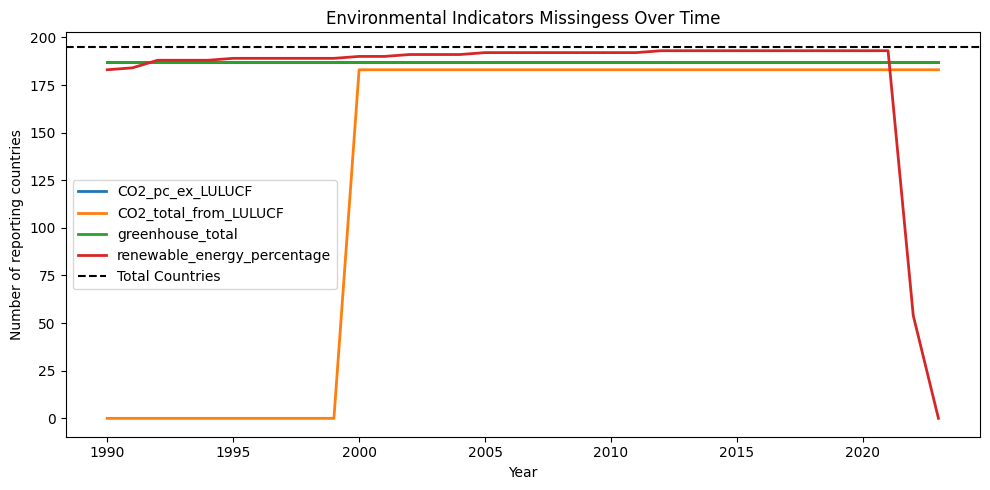

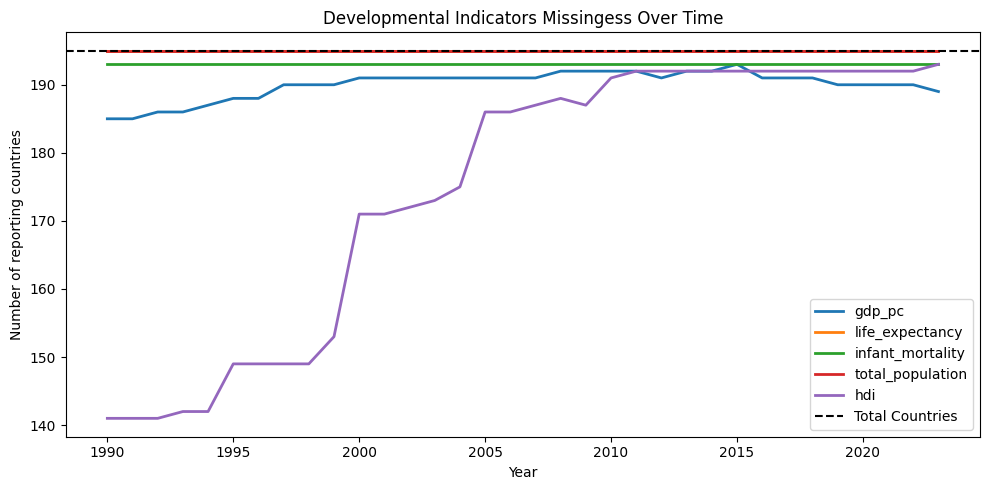

In [ ]:
"""
  Available indicators:
    - gdp_pc - # GDP per capita adjusted to inflation
    - CO2_pc_ex_LULUCF - CO2 per capita excluding LULUCF (tonnes / capita)
    - CO2_total_from_LULUCF - CO2 from LULUCF (Mega tonne)
    - greenhouse_total - total greenshouse emissions including LULUCF
    - renewable_energy_percentage - renewable energy consumption % of total energy consumption)
    - life_expectancy - Life expectancy (years)
    - infant_mortality - Infant mortality rate (per 1000 births)
    - total_population - Total Population
    - hdi - Human Development Index (0-1)
"""

environmental_indicators = ["CO2_pc_ex_LULUCF", "CO2_total_from_LULUCF", "greenhouse_total", "renewable_energy_percentage"]
developmental_indicators = ["gdp_pc", "life_expectancy", "infant_mortality", "total_population", "hdi"]

# Count reporting countries per year per variable
def plot_missingness_over_time(df, indicators, title, file_name):
  reporting_over_time = (
      df.groupby("year")[indicators]
      .apply(lambda x: x.notna().sum())
      .reset_index()
  )

  fig, ax = plt.subplots(figsize=(10, 5))
  for var in indicators:
      ax.plot(reporting_over_time["year"], reporting_over_time[var], label=var, linewidth=2)

  ax.axhline(y = 195, color = "black", linestyle = "--", label = "Total Countries")

  ax.set_xlabel("Year")
  ax.set_ylabel("Number of reporting countries")
  ax.set_title(title)
  ax.legend()
  plt.tight_layout()
  plt.savefig(f"{file_name}.png", dpi=150, bbox_inches="tight")
  plt.show()

plot_missingness_over_time(df_merged, environmental_indicators, "Environmental Indicators Missingess Over Time", "missing_environmental_indicators_over_time")
plot_missingness_over_time(df_merged, developmental_indicators, "Developmental Indicators Missingess Over Time", "missing_developmental_indicators_over_time")

#### **Missingness by Country**

In [ ]:
# Summary statistics for NAs count per year per indicator
na_by_country = (
    df_merged
    .groupby("country") [
        ["CO2_pc_ex_LULUCF", "greenhouse_total", "renewable_energy_percentage", "hdi", "gdp_pc", "infant_mortality"]
    ]
    .apply(lambda x: x.isnull().sum())
)
print("\n --- Countries and the number of missing data they have ---")
display(na_by_country[na_by_country.sum(axis=1) > 1])


 --- Countries and the number of missing data they have ---


,CO2_pc_ex_LULUCF,greenhouse_total,renewable_energy_percentage,hdi,gdp_pc,infant_mortality
country,,,,,,
Afghanistan,0,0,1,0,10,0
Albania,0,0,2,0,0,0
Algeria,0,0,2,0,0,0
Andorra,34,34,1,10,0,0
Angola,0,0,2,9,0,0
...,...,...,...,...,...,...
Viet Nam,0,0,2,0,0,0
West Bank and Gaza,34,34,1,14,4,0
"Yemen, Rep.",0,0,2,0,5,0


## **Visualisations**

### **Pair Plots**

In [14]:
environmental_indicators = ["CO2_pc_ex_LULUCF", "CO2_total_from_LULUCF", "greenhouse_total", "renewable_energy_percentage"]
developmental_indicators = ["gdp_pc", "life_expectancy", "infant_mortality", "hdi"]

income_palette = {
    "HIC": "#2196F3",
    "UMC": "#4CAF50",
    "LMC": "#FF9800",
    "LIC": "#F44336",
    "INX": "#9E9E9E"
}

def pair_plot(df, year, x_indicators, y_indicators=None, title=None, file_name=None, colour_by_income=False):
    """
    If y_indicators is None, standard pair plot.
    If y_indicators is provided, plots x_indicators vs y_indicators.
    """
    df_year = df[df["year"] == year].copy()

    all_indicators = x_indicators if y_indicators is None else x_indicators + y_indicators
    required = all_indicators + (["income_level"] if colour_by_income else [])
    df_year = df_year[required].dropna()

    if y_indicators is None:
        # Standard square pairplot
        plot = sns.pairplot(
            df_year,
            vars=x_indicators,
            hue="income_level" if colour_by_income else None,
            palette=income_palette if colour_by_income else None,
            diag_kind="kde",
            plot_kws={"alpha": 0.6, "s": 20},
            diag_kws={"fill": True}
        )
        fig = plot.figure

    else:
        # Rectangular PairGrid — x_indicators on x axis, y_indicators on y axis
        g = sns.PairGrid(
            df_year,
            x_vars=x_indicators,
            y_vars=y_indicators,
        )
        if colour_by_income:
            g.map(sns.scatterplot, hue=df_year["income_level"],
                  palette=income_palette, alpha=0.6, s=20)
            g.add_legend(title="Income Level", bbox_to_anchor=(1.05, 0.5), loc="center left")
        else:
            g.map(sns.scatterplot, alpha=0.6, s=20, color="steelblue")
        fig = g.figure

    if title:
        fig.suptitle(title, y=1.02, fontsize=14)

    plt.tight_layout()
    if file_name:
        plt.savefig(f"{file_name}.png", dpi=150, bbox_inches="tight")
    plt.show()


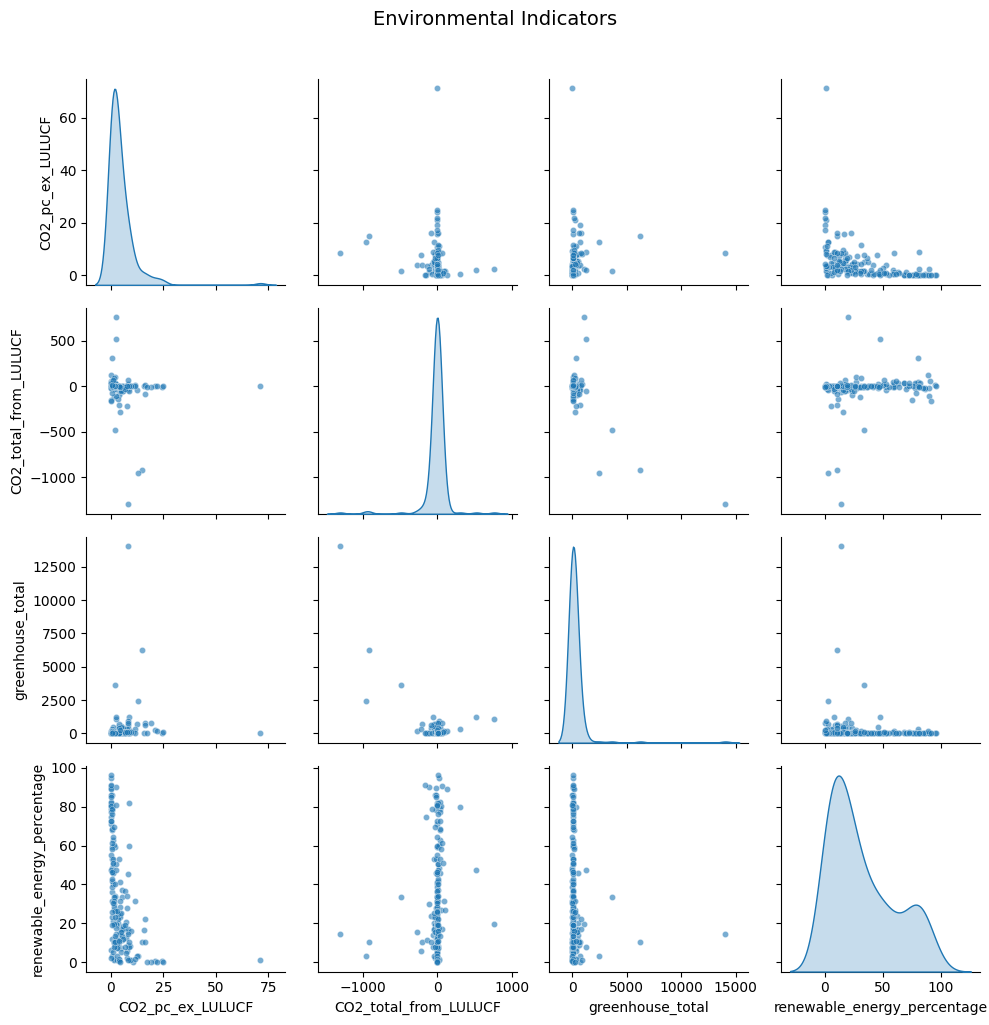

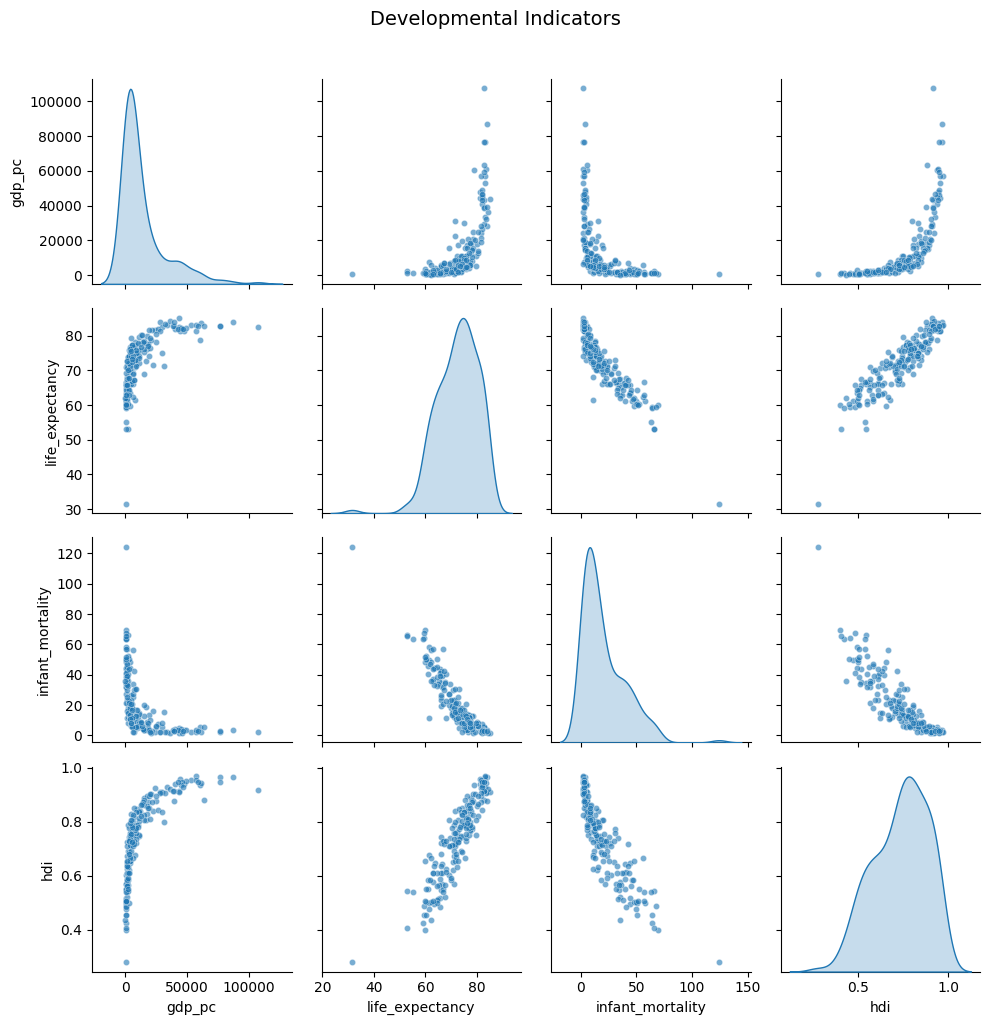

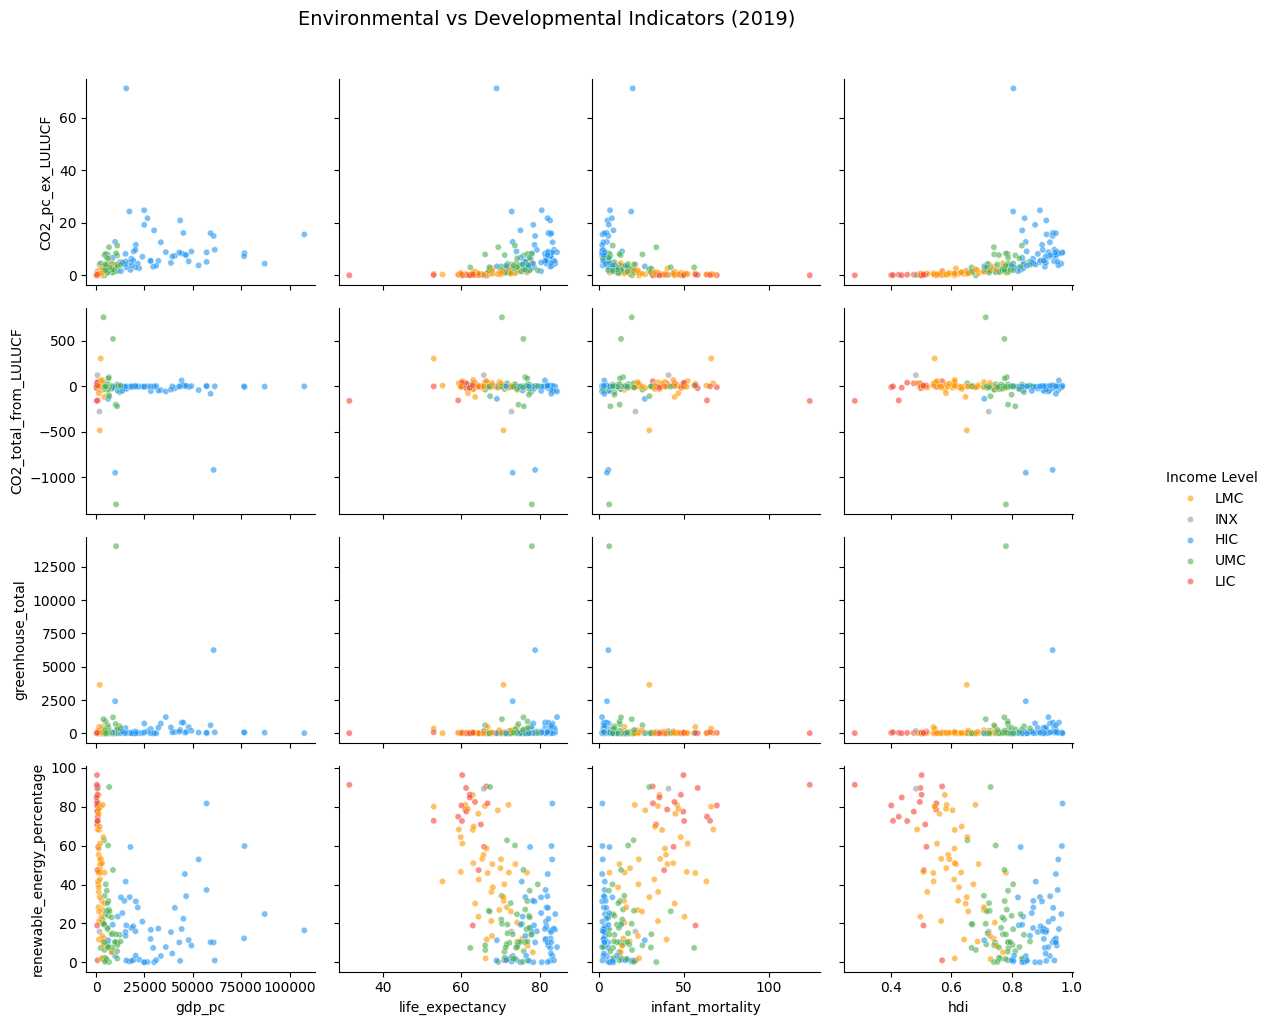

In [15]:
pair_plot(df_merged, 2019, environmental_indicators,
          title="Environmental Indicators", file_name="pairplot_environmental")

pair_plot(df_merged, 2019, developmental_indicators,
          title="Developmental Indicators", file_name="pairplot_developmental")

# Cross-category plot
pair_plot(df_merged, 2019,
          x_indicators=developmental_indicators,
          y_indicators=environmental_indicators,
          title="Environmental vs Developmental Indicators (2019)",
          file_name="pairplot_cross",
          colour_by_income=True)

### **Correlation Heat Map**

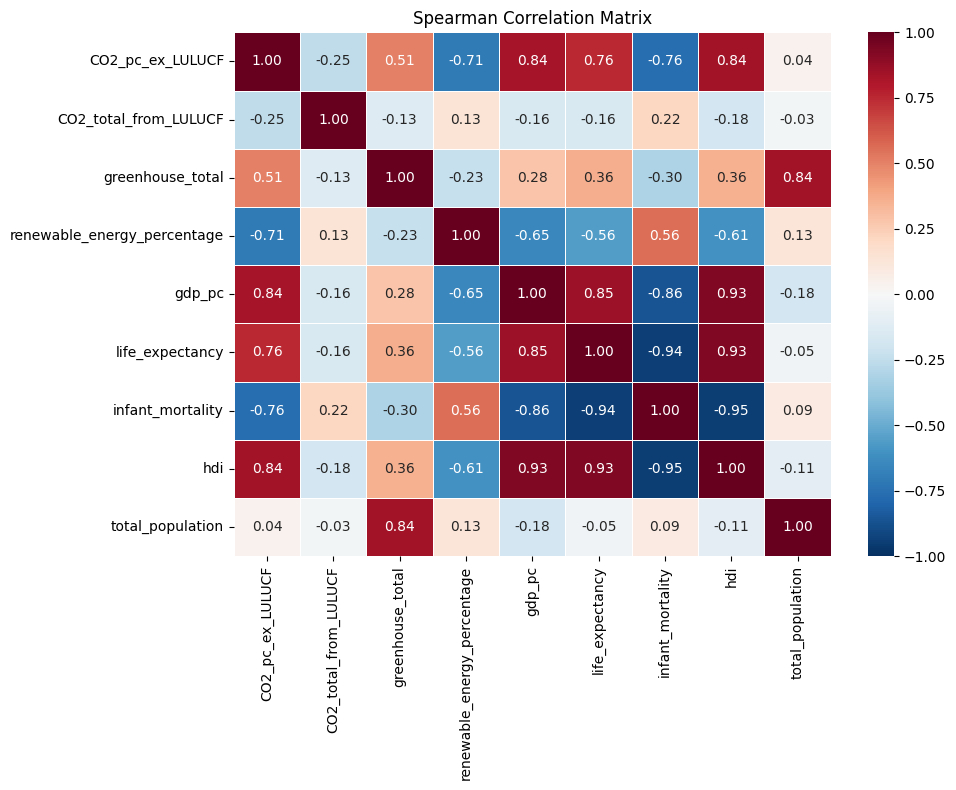

In [ ]:
corr = df_merged[environmental_indicators + developmental_indicators + ["total_population"]].corr(method="spearman")

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5
)
plt.title("Spearman Correlation Matrix")
plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

### **Animation**

In [17]:
def animate_over_time(
    df,
    x_var,
    y_var,
    file_name,
    x_label,
    y_label,
    title = None,
    log_y_scale = False,
    log_x_scale = False,
    filter_positive_y = True,
    filter_positive_x = True,
    colour_by_income = False,
    show_best_fit = False,
    year_text_loc = "top_right",
    steps_per_year = 20,
    fps = 30,
    figsize = (9, 6),
    x_min = None,
    x_max = None
):

  # Colour Mapping
  income_colours = {
    "HIC": "#2196F3",
    "UMC": "#4CAF50",
    "LMC": "#FF9800",
    "LIC": "#F44336",
    "INX": "#9E9E9E"
  }
  income_labels = {
    "HIC": "High Income",
    "UMC": "Upper Middle Income",
    "LMC": "Lower Middle Income",
    "LIC": "Low Income",
    "INX": "Not Classified"
  }

  corners = {
    "top_right":    (0.97, 0.95, "right", "top"),
    "top_left":     (0.03, 0.95, "left",  "top"),
    "bottom_right": (0.97, 0.05, "right", "bottom"),
    "bottom_left":  (0.03, 0.05, "left",  "bottom"),
  }
  x_pos, y_pos, ha, va = corners.get(year_text_loc, corners["top_right"])


  # Filter data
  required_columns = [x_var, y_var, "iso3", "year"]
  if colour_by_income:
    required_columns.append("income_level")

  df_anim = df.dropna(subset = required_columns).copy()
  df_anim = df_anim.sort_values(["iso3", "year"])

  if filter_positive_y:
    df_anim = df_anim[df_anim[y_var] > 0].copy()
  if filter_positive_x:
    df_anim = df_anim[df_anim[x_var] > 0].copy()

  years = sorted(df_anim["year"].unique())

  # Ensure axis limits are slightly below\above all the data points
  if x_min is None:
    xmin = df_anim[x_var].min() * 0.95
  else:
    xmin = x_min
  if x_max is None:
    xmax = df_anim[x_var].max() * 1.05
  else:
    xmax = x_max

  ymax = df_anim[y_var].max()

  if log_y_scale:
    ymin = df_anim[y_var][df_anim[y_var] > 0].min() * 0.8
  elif df_anim[y_var].min() < 0:
    ymin = df_anim[y_var].min() * 1.1  # buffer below most negative value
  else:
    ymin = 0

  if log_x_scale:
    xmin = x_min if x_min is not None else df_anim[x_var][df_anim[x_var] > 0].min() * 0.8
  else:
    xmin = x_min if x_min is not None else df_anim[x_var].min() * 0.95


  # Linear interpolation for between each year
  def get_interpolated_frame(year_from, year_to, t):
    d0 = df_anim[df_anim["year"] == year_from].set_index("iso3")
    d1 = df_anim[df_anim["year"] == year_to].set_index("iso3")

    common = d0.index.intersection(d1.index)

    x_interp = d0.loc[common, x_var] * (1 - t) + d1.loc[common, x_var] * t
    y_interp = d0.loc[common, y_var] * (1 - t) + d1.loc[common, y_var] * t

    if colour_by_income:
        colours = d0.loc[common, "income_level"].map(income_colours).fillna("gray")

        return x_interp.values, y_interp.values, colours.values

    return x_interp.values, y_interp.values, None

  # Build frames
  all_frames = []
  for i, year in enumerate(years):

    if i < len(years) - 1:
      next_year = years[i + 1]

      for step in range(steps_per_year):
        t = step / steps_per_year

        x_vals, y_vals, colours = get_interpolated_frame(year, next_year, t)

        label = str(year) if t < 0.5 else str(next_year)

        all_frames.append((x_vals, y_vals, colours,label))
    else:
      d = df_anim[df_anim["year"] == year]

      colours = d["income_level"].map(income_colours).fillna("gray").values if colour_by_income else None

      for _ in range(steps_per_year):
        all_frames.append((d[x_var].values, d[y_var].values, colours, str(year)))

  # Plot
  fig, ax = plt.subplots(figsize=figsize)

  ax.set_xlim(xmin, xmax)
  ax.set_ylim(ymin, ymax * 1.1)

  if log_y_scale:
    ax.set_yscale("log")

  if log_x_scale:
    ax.set_xscale("log")

  ax.set_xlabel(x_label or x_var, fontsize=12)
  ax.set_ylabel(y_label or y_var, fontsize=12)

  if title:
    ax.set_title(title, fontsize=13)

  if colour_by_income:
    scat = ax.scatter([], [], alpha=0.8, s=30, edgecolors="white", linewidths=0.3)
  else:
    scat = ax.scatter([], [], alpha=0.8, s=30, c="steelblue", edgecolors="white", linewidths=0.3)

  year_text = ax.text(x_pos, y_pos, "", transform=ax.transAxes,
                    fontsize=22, ha=ha, va=va,
                    fontweight="bold", color="black")

  if show_best_fit:
    line, = ax.plot([], [], color="red", linewidth=1.5, linestyle="--", alpha=0.8, label="Best fit")

  if colour_by_income:

    legend_elements = [
      Line2D([0], [0], marker="o", color="w", markerfacecolor=col,
             markersize=8, label=income_labels[income])
      for income, col in income_colours.items()
    ]
    if show_best_fit:
      legend_elements.append(MLine([0], [0], color="red", linewidth=1.5, linestyle="--", alpha=0.8, label="Best fit"))

    ax.legend(handles=legend_elements, loc="lower right", fontsize=9)


  elif show_best_fit:
    ax.legend(loc = "lower right", fontsize = 9)

  year_text = ax.text(x_pos, y_pos, "", transform=ax.transAxes,
                      fontsize=22, ha=ha, va=va,
                      fontweight="bold", color="black")

  def update(frame_idx):
    x_vals, y_vals, colours, label = all_frames[frame_idx]
    scat.set_offsets(np.column_stack([x_vals, y_vals]))
    if colour_by_income and colours is not None:
      scat.set_facecolor(colours)
    year_text.set_text(label)

    if show_best_fit and len(x_vals) > 2:
      x_fit = np.log(x_vals) if log_x_scale else x_vals
      y_fit = np.log(y_vals) if log_y_scale else y_vals

      valid = np.isfinite(x_fit) & np.isfinite(y_fit)

      if valid.sum() > 2:
        m, b = np.polyfit(x_fit[valid], y_fit[valid], 1)
        x_line = np.linspace(xmin, xmax, 100)
        x_line_fit = np.log(x_line) if log_x_scale else x_line
        y_line = m * x_line_fit + b
        if log_y_scale:
          y_line = np.exp(y_line)
        line.set_data(x_line, y_line)

    return scat, year_text, line

  anim = FuncAnimation(fig, update, frames=len(all_frames), interval=50, blit=False)
  anim.save(file_name, writer="ffmpeg", fps=fps)
  plt.close()


In [18]:
animate_over_time(
    df_merged, "hdi", "CO2_pc_ex_LULUCF",
    file_name="co2_hdi.mp4",
    x_label="Human Development Index (HDI)",
    y_label="CO2 per capita (t CO2e) — log scale",
    log_y_scale=True,
    show_best_fit = True,
    colour_by_income = True,
    x_min=0.3, x_max=1.0
)

In [ ]:
animate_over_time(
    df_merged, "hdi", "gdp_pc",
    file_name="gdp_pc_hdi.mp4",
    x_label="Human Development Index (HDI)",
    y_label="GDP per Capita (USD, 2015 prices) ",
    log_y_scale=True,
    x_min=0.3, x_max=1.0
)

In [ ]:
animate_over_time(
    df_merged, "hdi", "life_expectancy",
    file_name="life_expectancy_hdi.mp4",
    x_label="Human Development Index (HDI)",
    y_label="Life Expectancy (Years)",
    x_min=0.3, x_max=1.0
)

In [ ]:
animate_over_time(
    df_merged, "gdp_pc", "CO2_pc_ex_LULUCF",
    file_name="gdp_co2_income_level.mp4",
    x_label="GDP per Capita (USD, 2015 prices) - log scale",
    y_label="CO2 per Capita (t CO2e) - log scale",
    title="GDP per Capita vs CO2 Emissions per Capita",
    log_x_scale=True,
    log_y_scale=True,
    filter_positive_x=True,
    colour_by_income=True,
    year_text_loc="top_left"
)

In [ ]:
animate_over_time(
    df_merged, "hdi", "infant_mortality",
    file_name="infant_mortality_hdi.mp4",
    x_label="Human Development Index (HDI)",
    y_label="Infant Mortality (per 1000 Live Births)",
    x_min=0.3, x_max=1.0
)

In [ ]:
animate_over_time(
    df_merged, "renewable_energy_percentage", "CO2_pc_ex_LULUCF",
    file_name="co2_renewable_energy.mp4",
    x_label="Renewable Energy Consumption (% of total final energy consumption)",
    y_label="CO2 per capita (t CO2e) — log scale",
    x_min=0.3, x_max=1.0
)

In [ ]:
animate_over_time(
    df_merged, "hdi", "CO2_total_from_LULUCF",
    file_name="lulucf_hdi.mp4",
    x_label="Human Development Index (HDI)",
    y_label="CO2 per capita (t CO2e) — log scale",
    log_y_scale=False,
    filter_positive_y=False
)

# **Data Wrangling**

## **Fixing naming issues**
Notice, because we used ISO3 codes rather than Country names, there were not any issues with our merging.

In [ ]:
print("\n--- Unique Countries ---")
df_merged['country'] = df_merged['country'].str.strip().str.upper()
print(df_merged['country'].unique())


--- Unique Countries ---
['ZIMBABWE' 'ZAMBIA' 'YEMEN, REP.' 'WEST BANK AND GAZA' 'VIET NAM'
 'VENEZUELA, RB' 'VANUATU' 'UZBEKISTAN' 'URUGUAY' 'UNITED STATES'
 'UNITED KINGDOM' 'UNITED ARAB EMIRATES' 'UKRAINE' 'UGANDA' 'TUVALU'
 'TURKMENISTAN' 'TURKIYE' 'TUNISIA' 'TRINIDAD AND TOBAGO' 'TONGA' 'TOGO'
 'TIMOR-LESTE' 'THAILAND' 'TANZANIA' 'TAJIKISTAN' 'SYRIAN ARAB REPUBLIC'
 'SWITZERLAND' 'SWEDEN' 'SURINAME' 'SUDAN'
 'ST. VINCENT AND THE GRENADINES' 'ST. LUCIA' 'ST. KITTS AND NEVIS'
 'SRI LANKA' 'SPAIN' 'SOUTH SUDAN' 'SOUTH AFRICA' 'SOMALIA, FED. REP.'
 'SOLOMON ISLANDS' 'SLOVENIA' 'SLOVAK REPUBLIC' 'SINGAPORE' 'SIERRA LEONE'
 'SEYCHELLES' 'SERBIA' 'SENEGAL' 'SAUDI ARABIA' 'SAO TOME AND PRINCIPE'
 'SAN MARINO' 'SAMOA' 'RWANDA' 'RUSSIAN FEDERATION' 'ROMANIA' 'QATAR'
 'PORTUGAL' 'POLAND' 'PHILIPPINES' 'PERU' 'PARAGUAY' 'PAPUA NEW GUINEA'
 'PANAMA' 'PALAU' 'PAKISTAN' 'OMAN' 'NORWAY' 'NORTH MACEDONIA' 'NIGERIA'
 'NIGER' 'NICARAGUA' 'NEW ZEALAND' 'NETHERLANDS' 'NEPAL' 'NAURU' 'NAMIBIA'
 'MYANM

## **Analysis null values**

Below is a list of territories that are listed in pycountry but not in our data set. It is important to note that, other than Vatican City, none of these are countries, and so it makes sense that they're not included in our analysis.

In [ ]:
# Get all available iso3 codes from pycountry
iso3_codes = [country.alpha_3 for country in pycountry.countries]

df_merged_iso3=(df_merged['iso3'].tolist())
#for i in iso3_codes:
 # country = pycountry.countries.get(alpha_3=i)
  #if i in df_merged_iso3:
   # print(f"{country.name} is in our data set")
print("\n ---- Not in our data set ----")
for i in iso3_codes:
  country = pycountry.countries.get(alpha_3=i)
  if i not in df_merged_iso3:
    print(country.name)
#i want to change this to printing country names so that its more readable



 ---- Not in our data set ----
Aruba
Anguilla
Åland Islands
American Samoa
Antarctica
French Southern Territories
Bonaire, Sint Eustatius and Saba
Saint Barthélemy
Bermuda
Bouvet Island
Cocos (Keeling) Islands
Cook Islands
Curaçao
Christmas Island
Cayman Islands
Western Sahara
Falkland Islands (Malvinas)
Faroe Islands
Guernsey
Gibraltar
Guadeloupe
Greenland
French Guiana
Guam
Heard Island and McDonald Islands
Isle of Man
British Indian Ocean Territory
Jersey
Macao
Saint Martin (French part)
Northern Mariana Islands
Montserrat
Martinique
Mayotte
New Caledonia
Norfolk Island
Niue
Pitcairn
Puerto Rico
French Polynesia
Réunion
South Georgia and the South Sandwich Islands
Saint Helena, Ascension and Tristan da Cunha
Svalbard and Jan Mayen
Saint Pierre and Miquelon
Sint Maarten (Dutch part)
Turks and Caicos Islands
Tokelau
Taiwan, Province of China
United States Minor Outlying Islands
Holy See (Vatican City State)
Virgin Islands, British
Virgin Islands, U.S.
Wallis and Futuna


Now, this shows the missing data within our data set.

In [ ]:
#now I want to find countries in our data set with any missing values, and say what year and what indexes theyre missing


countries=(df_merged['country'].unique())


for c in countries:
  country_df = df_merged[df_merged["country"] == c]  # filter that country
  print(f"\nCountry: {c}")
  for col in df_merged.columns:
    if col not in ["country", "year","iso3", "region", "income_level"]:  # skip identifier columns

      missing = country_df[country_df[col].isnull()]

      if not missing.empty:  # only print if something is missing
        print(f"  Missing values in {col}:")
        print(missing[["year", col]])
      else:
        print(f"no missing values in {col} for {c} ")


Streaming output truncated to the last 5000 lines.
1697  1992  NaN
1698  1991  NaN
1699  1990  NaN
no missing values in region_name for SAMOA 

Country: RWANDA
  Missing values in renewable_energy_percentage:
      year  renewable_energy_percentage
1700  2023                          NaN
no missing values in greenhouse_total for RWANDA 
  Missing values in CO2_total_from_LULUCF:
      year  CO2_total_from_LULUCF
1724  1999                    NaN
1725  1998                    NaN
1726  1997                    NaN
1727  1996                    NaN
1728  1995                    NaN
1729  1994                    NaN
1730  1993                    NaN
1731  1992                    NaN
1732  1991                    NaN
1733  1990                    NaN
no missing values in CO2_pc_ex_LULUCF for RWANDA 
no missing values in gdp_pc for RWANDA 
no missing values in infant_mortality for RWANDA 
no missing values in life_expectancy for RWANDA 
no missing values in total_population for RWANDA 
  Mis

We have a mix of countries with all data missing, and countries with only a bit of data missing.

Venezuela and Ethiopia have an undefined income level (INX)

In [ ]:
def classify_missingness(df, variable):
  summary = df.groupby("iso3")[variable].apply(
      lambda x: "Always Missing" if x.isnull().all()
      else "Partially Missing" if x.isnull().any()
      else "Complete"
  ).reset_index()

  summary.columns = ["iso3", "status"]

  return summary

co2_status = classify_missingness(df_merged, "CO2_pc_ex_LULUCF")
hdi_status = classify_missingness(df_merged, "hdi")

co2_status = co2_status.merge(
    wb_metadata,
    on = "iso3",
    how = "inner"
)

hdi_status = hdi_status.merge(
    wb_metadata,
    on = "iso3",
    how = "inner"
)

print("---- World regions ----")
print(df_merged["region_name"].unique())
print("---- CO2 Missigness by region ----")
display(co2_status.groupby(["region_name", "status"]).size().unstack(fill_value=0))

print("---- HDI Missigness by region ----")
display(hdi_status.groupby(["region_name", "status"]).size().unstack(fill_value = 0))


print("---- HDI Missingness by income group ----")
display(hdi_status.groupby(["income_level", "status"]).size().unstack(fill_value = 0))

---- World regions ----
['Sub-Saharan Africa' 'Middle East & North America' 'East Asia & Pacific'
 'Latin America & Caribbean' 'Europe & Central Asia' 'South Asia']
---- CO2 Missigness by region ----


status,Always Missing,Complete
region_name,,
East Asia & Pacific,0,31
Europe & Central Asia,6,46
Latin America & Caribbean,0,33
Middle East & North America,1,22
South Asia,0,6
Sub-Saharan Africa,1,49


---- HDI Missigness by region ----


status,Always Missing,Complete,Partially Missing
region_name,,,
East Asia & Pacific,1,21,9
Europe & Central Asia,1,37,14
Latin America & Caribbean,0,27,6
Middle East & North America,0,19,4
South Asia,0,4,2
Sub-Saharan Africa,0,32,18


---- HDI Missingness by income group ----


status,Always Missing,Complete,Partially Missing
income_level,,,
HIC,1,54,10
INX,0,1,1
LIC,1,13,11
LMC,0,36,14
UMC,0,36,17


## Analysing Outliers

Looking at Palau as it has the highest CO2 emissions per capita since early 2000s

And the countries which have recorded the lowest CO2 emissions per capita, Micronesia (Federated States of)	and Marshall Islands.

Some countries which have reported 0 tonnes CO2 emissions per capita Nauru and Tuvalu

### **Identifying possible outliers**
Possible outliers and issues with the data are:
- The mean CO$_2$ is 4.97 whereas the maxium CO$_2$ is 202.87.
- The minimum life expectancy is 12.1 which doesn't seem plausable
- HDI is already rated from just 0-1 so no outliers to remove.

In [ ]:
#summary statistics for df_merged
print("\n--- Numerical Summary Statistics ---")
display(df_merged.drop(columns='year').describe())


--- Numerical Summary Statistics ---


,renewable_energy_percentage,greenhouse_total,CO2_total_from_LULUCF,CO2_pc_ex_LULUCF,gdp_pc,infant_mortality,life_expectancy,total_population,hdi
count,6157.000000,6358.000000,4392.000000,6358.000000,6461.000000,6562.000000,6630.000000,6.630000e+03,5940.000000
mean,33.432370,216.119598,-18.032976,4.974422,12411.279603,32.269445,68.717569,3.424298e+07,0.683066
std,30.591045,910.652808,182.165509,9.875278,19474.974490,31.149694,9.568064,1.301847e+08,0.164983
min,0.000000,0.001000,-1744.682900,0.000000,166.710440,1.400000,12.158000,8.798000e+03,0.215000
25%,6.000000,7.896650,-12.010700,0.524995,1452.186583,8.500000,62.941250,1.662257e+06,0.564000
50%,24.000000,29.320800,-1.073700,2.063040,4279.615471,20.300000,70.580976,6.974010e+06,0.706000
75%,57.100000,100.007925,2.200500,6.369809,14050.313558,47.200000,75.711896,2.243034e+07,0.809250
max,98.300000,15411.783400,2475.107800,202.865184,225884.183304,274.000000,86.372000,1.438070e+09,0.972000


Log transformations and removing Null values.

In [ ]:
df_merged_clean = df_merged.copy()

#For Tuvalu and Nauru add NaN to their co2 emissions as consistently reporting 0 is not realistic
df_merged_clean.loc[df_merged_clean["CO2_pc_ex_LULUCF"] == 0, "CO2_pc_ex_LULUCF"] = np.nan

# Log transformations
df_merged_clean["log_co2"] = np.log(df_merged_clean["CO2_pc_ex_LULUCF"])
df_merged_clean["log_gdp_pc"] = np.log(df_merged_clean["gdp_pc"])

df_merged_clean = df_merged_clean.dropna(subset = ["log_co2", "log_gdp_pc", "hdi"])

df_merged_clean = df_merged_clean.set_index(["iso3", "year"])

One outlier that we should remove is that our minimum life expecancy is 12.158.

In [ ]:
print("\n--- Numerical Summary Statistics ---")
display(df_merged_clean.describe())


--- Numerical Summary Statistics ---


,renewable_energy_percentage,greenhouse_total,CO2_total_from_LULUCF,CO2_pc_ex_LULUCF,gdp_pc,infant_mortality,life_expectancy,total_population,hdi,log_co2,log_gdp_pc
count,5363.000000,5685.000000,4035.000000,5685.000000,5685.000000,5651.000000,5685.000000,5.685000e+03,5685.000000,5685.000000,5685.000000
mean,33.053235,239.360173,-19.463583,5.138994,12291.707066,29.933835,69.290162,3.912237e+07,0.682933,0.610988,8.489471
std,30.225044,960.330396,189.938200,8.751106,17235.194777,28.129991,9.041667,1.399478e+08,0.163718,1.689230,1.438305
min,0.000000,0.002900,-1744.682900,0.001776,166.710440,1.600000,31.530000,1.764800e+04,0.215000,-6.333546,5.116258
25%,6.000000,10.135500,-13.231750,0.648354,1507.818729,8.000000,63.773000,2.567801e+06,0.563000,-0.433318,7.318419
50%,24.000000,33.754900,-1.478000,2.381582,4457.275375,18.800000,71.053171,8.546900e+06,0.707000,0.867765,8.402293
75%,56.650000,123.456500,2.574150,6.822838,15633.909113,44.600000,76.059000,2.680811e+07,0.807000,1.920276,9.657197
max,98.300000,15411.783400,2475.107800,202.865184,112417.876989,146.700000,85.532683,1.438070e+09,0.972000,5.312542,11.629978


**Outliers of features**

### Life expectancy

In [ ]:
print("---Lowest life epectancies---")
sorted_values = df_merged['life_expectancy'].sort_values().unique()
first_few=sorted_values[:31]
for i in first_few:
  row = df_merged[df_merged['life_expectancy'] == i ][['country','year','life_expectancy']]
  print(f'\n{row.to_string(index=False)}')
print("\n---Highest life epectancies---")
sorted_values = df_merged['life_expectancy'].sort_values(ascending=False).unique()
first_few=sorted_values[:11]
for i in first_few:
  row = df_merged[df_merged['life_expectancy'] == i ][['country','year','life_expectancy']]
  print(f'\n{row.to_string(index=False)}')




---Lowest life epectancies---

country  year  life_expectancy
 RWANDA  1994           12.158

                 country  year  life_expectancy
CENTRAL AFRICAN REPUBLIC  2009           14.665

                 country  year  life_expectancy
CENTRAL AFRICAN REPUBLIC  2022           18.818

    country  year  life_expectancy
SOUTH SUDAN  1998           19.048

    country  year  life_expectancy
SOUTH SUDAN  1992           21.938

    country  year  life_expectancy
SOUTH SUDAN  1993           22.263

           country  year  life_expectancy
SOMALIA, FED. REP.  1992           25.034

           country  year  life_expectancy
SOMALIA, FED. REP.  1991           25.418

    country  year  life_expectancy
SOUTH SUDAN  1990           28.628

    country  year  life_expectancy
SOUTH SUDAN  1991           29.185

    country  year  life_expectancy
SOUTH SUDAN  1995            31.51

                 country  year  life_expectancy
CENTRAL AFRICAN REPUBLIC  2019            31.53

    country  year  

In [ ]:
def determine_outlier_thresholds_iqr(dataframe,col_name):
    quartile1= dataframe.describe()[col_name]['25%']
    quartile3= dataframe.describe()[col_name]['75%']
    iqr = quartile3 - quartile1
    upper_limit = quartile3 + 1.5 * iqr
    lower_limit = max(0, quartile1 - 1.5 * iqr)
    return lower_limit, upper_limit

In [ ]:
print(f"Old Min life expectancy: {df_merged['life_expectancy'].min()}, Old Max life expectancy: {df_merged['life_expectancy'].max()}")
limits_l_e=(determine_outlier_thresholds_iqr(df_merged_clean,'life_expectancy'))
print(limits_l_e)
valid_range_l_e = (df_merged_clean['life_expectancy'] > limits_l_e[0]) & (df_merged_clean['life_expectancy'] < limits_l_e[1])
df_merged_clean = df_merged_clean[valid_range_l_e]

print(f"Removed outliers. New Min life expectancy: {df_merged_clean['life_expectancy'].min()} New Max life expectancy: {df_merged_clean['life_expectancy'].max()}")

Old Min life expectancy: 12.158, Old Max life expectancy: 86.372
(np.float64(46.34212500000001), np.float64(90.64112499999999))
Removed outliers. New Min life expectancy: 46.344 New Max life expectancy: 84.56


trying to see how it would look if we removed outliers a different way, we can see this doesn't work as it flags normal life expectancies. Hence, we will not use this method to remove outliers.

In [ ]:
years=df_merged['year']
years=(years).sort_values()
np.array(years)

array([1990, 1990, 1990, ..., 2023, 2023, 2023])

In [ ]:
for i in countries:
  print(f" \n {i}")
  country_data = df_merged[df_merged['country'] == i]

  # Calculate absolute difference year-on-year
  difference = country_data['life_expectancy'].diff().abs()
  difference=difference[1:]
  #print(np.array(difference))
  # Convert to NumPy array and store in dictionary
  #calculating the threshold
  threshold = difference.mean()+3*difference.std()
  flagged_indices = difference[difference > threshold].index

  # Print year and life expectancy for flagged rows
  for idx in flagged_indices:
    print(f"Year: {country_data.loc[idx, 'year']}, Life Expectancy: {country_data.loc[idx, 'life_expectancy']}")

 
 ZIMBABWE
 
 ZAMBIA
Year: 2021, Life Expectancy: 62.363
 
 YEMEN, REP.
Year: 2021, Life Expectancy: 66.019
 
 WEST BANK AND GAZA
Year: 2022, Life Expectancy: 76.662
 
 VIET NAM
Year: 2020, Life Expectancy: 75.383
Year: 2019, Life Expectancy: 74.211
 
 VENEZUELA, RB
Year: 2001, Life Expectancy: 71.019
 
 VANUATU
Year: 2021, Life Expectancy: 69.952
 
 UZBEKISTAN
 
 URUGUAY
Year: 2020, Life Expectancy: 78.381
 
 UNITED STATES
Year: 2019, Life Expectancy: 78.7878048780488
 
 UNITED KINGDOM
Year: 2019, Life Expectancy: 81.3691219512195
 
 UNITED ARAB EMIRATES
Year: 2020, Life Expectancy: 81.936
 
 UKRAINE
Year: 2020, Life Expectancy: 73.283
 
 UGANDA
 
 TUVALU
Year: 1992, Life Expectancy: 60.29
Year: 1991, Life Expectancy: 61.809
 
 TURKMENISTAN
 
 TURKIYE
Year: 2021, Life Expectancy: 75.722
 
 TUNISIA
Year: 2021, Life Expectancy: 72.893
 
 TRINIDAD AND TOBAGO
Year: 2021, Life Expectancy: 71.111
 
 TONGA
Year: 2021, Life Expectancy: 72.13
 
 TOGO
Year: 2021, Life Expectancy: 61.328
 
 TIM

### **infant mortality**

In [ ]:
print("--- Highest infant mortalities---")
descending_values = df_merged['infant_mortality'].sort_values(ascending=False).unique()
top_few=descending_values[:11]
for i in top_few:
  row = df_merged[df_merged['infant_mortality'] == i ][['country','year','infant_mortality']]
  print(f'\n{row.to_string(index=False)}')
print("\n--- lowest infant mortalities---")
ascending_values = df_merged['infant_mortality'].sort_values().unique()
bottom_few=ascending_values[:31]
for i in bottom_few:
  row = df_merged[df_merged['infant_mortality'] == i ][['country','year','infant_mortality']]
  print(f'\n{row.to_string(index=False)}')

--- Highest infant mortalities---

           country  year  infant_mortality
SOMALIA, FED. REP.  1992             274.0

           country  year  infant_mortality
SOMALIA, FED. REP.  1991             264.9

                 country  year  infant_mortality
CENTRAL AFRICAN REPUBLIC  2009             234.9

    country  year  infant_mortality
SOUTH SUDAN  1998             234.6

           country  year  infant_mortality
SOMALIA, FED. REP.  2011             215.7

country  year  infant_mortality
 RWANDA  1994             212.2

                 country  year  infant_mortality
CENTRAL AFRICAN REPUBLIC  2022             189.1

    country  year  infant_mortality
SOUTH SUDAN  2017             172.9

country  year  infant_mortality
LIBERIA  1991             170.9

country  year  infant_mortality
LIBERIA  1992             170.5

country  year  infant_mortality
LIBERIA  1990             169.6

--- lowest infant mortalities---

   country  year  infant_mortality
SAN MARINO  2023               

In [ ]:
print(f"Old Min infant mortality rate: {df_merged['infant_mortality'].min()}, Old Max infant mortality rate: {df_merged['infant_mortality'].max()}")

limits_i_m=(determine_outlier_thresholds_iqr(df_merged_clean,'infant_mortality'))
print(limits_i_m)
valid_range_i_m = (df_merged_clean['infant_mortality'] > limits_i_m[0]) & (df_merged_clean['infant_mortality'] < limits_i_m[1])
df_merged_clean = df_merged_clean[valid_range_i_m]
print(f"Removed outliers. New Min infant mortality rate: {df_merged_clean['infant_mortality'].min()}, New Max infant mortality rate: {df_merged_clean['infant_mortality'].max()}")


Old Min infant mortality rate: 1.4, Old Max infant mortality rate: 274.0
(0, np.float64(97.64999999999999))
Removed outliers. New Min infant mortality rate: 1.6, New Max infant mortality rate: 97.6


### **gdp per capita**
can see in the code block below that no values were removed, so no outliers anyway.

In [ ]:
print(f"Old Min GDP per capita: {df_merged['gdp_pc'].min()}, Old Max GDP per capita: {df_merged['gdp_pc'].max()}")

limits_gdp=(determine_outlier_thresholds_iqr(df_merged_clean,'gdp_pc'))
print(limits_gdp)
valid_range_gdp = (df_merged_clean['gdp_pc'] > limits_gdp[0]) & (df_merged_clean['gdp_pc'] < limits_gdp[1])
df_merged_clean = df_merged_clean[valid_range_gdp]
print(f"Removed outliers. New Min GDP per capita: {df_merged_clean['gdp_pc'].min()}, New Max GDP per capita: {df_merged_clean['gdp_pc'].max()}")


Old Min GDP per capita: 166.71043994981, Old Max GDP per capita: 225884.183303985
(0, np.float64(37602.76744061391))
Removed outliers. New Min GDP per capita: 166.71043994981, New Max GDP per capita: 37580.5979329356


**Outliers of targets**

### CO$_2$

In [ ]:
print("--- Top contributors to CO2 from land use---")
descending_values = df_merged['CO2_total_from_LULUCF'].sort_values(ascending=False).unique()
top_few=descending_values[:31]
for i in top_few:
  row = df_merged[df_merged['CO2_total_from_LULUCF'] == i ][['country','year','CO2_total_from_LULUCF']]
  print(f'\n{row.to_string(index=False)}')
print("\n--- bottom contributors to CO2---")
ascending_values = df_merged['CO2_total_from_LULUCF'].sort_values().unique()
bottom_few=ascending_values[:31]
for i in bottom_few:
  row = df_merged[df_merged['CO2_total_from_LULUCF'] == i ][['country','year','CO2_total_from_LULUCF']]
  print(f'\n{row.to_string(index=False)}')

--- Top contributors to CO2 from land use---

country  year  CO2_total_from_LULUCF
 BRAZIL  2004              2475.1078

country  year  CO2_total_from_LULUCF
 BRAZIL  2003               2290.325

  country  year  CO2_total_from_LULUCF
INDONESIA  2015              1655.3836

country  year  CO2_total_from_LULUCF
 BRAZIL  2005              1474.2087

country  year  CO2_total_from_LULUCF
 BRAZIL  2002               1254.563

country  year  CO2_total_from_LULUCF
 BRAZIL  2006              1127.8363

country  year  CO2_total_from_LULUCF
 BRAZIL  2000              1108.0799

country  year  CO2_total_from_LULUCF
 BRAZIL  2001              1055.5153

  country  year  CO2_total_from_LULUCF
INDONESIA  2006               998.6136

  country  year  CO2_total_from_LULUCF
INDONESIA  2016               974.8411

  country  year  CO2_total_from_LULUCF
INDONESIA  2014               930.8481

country  year  CO2_total_from_LULUCF
 BRAZIL  2008               898.1821

  country  year  CO2_total_from_LULUCF

In [ ]:
print("--- Top contributors to CO2 excluding land use---")
descending_values = df_merged['CO2_pc_ex_LULUCF'].sort_values(ascending=False).unique()
top_few=descending_values[:31]
for i in top_few:
  row = df_merged[df_merged['CO2_pc_ex_LULUCF'] == i ][['country','year','CO2_pc_ex_LULUCF']]
  print(f'\n{row.to_string(index=False)}')
print("\n--- bottom contributors to CO2---")
ascending_values = df_merged['CO2_pc_ex_LULUCF'].sort_values().unique()
bottom_few=ascending_values[:31]
for i in bottom_few:
  row = df_merged[df_merged['CO2_pc_ex_LULUCF'] == i ][['country','year','CO2_pc_ex_LULUCF']]
  print(f'\n{row.to_string(index=False)}')


--- Top contributors to CO2 excluding land use---

country  year  CO2_pc_ex_LULUCF
  PALAU  2012        202.865184

country  year  CO2_pc_ex_LULUCF
  PALAU  1994        178.640429

country  year  CO2_pc_ex_LULUCF
  PALAU  1990        141.293663

country  year  CO2_pc_ex_LULUCF
  PALAU  1997        139.065606

country  year  CO2_pc_ex_LULUCF
  PALAU  1991        137.050083

country  year  CO2_pc_ex_LULUCF
  PALAU  1995        136.650189

country  year  CO2_pc_ex_LULUCF
  PALAU  2011        131.081978

country  year  CO2_pc_ex_LULUCF
  PALAU  1999        128.030263

country  year  CO2_pc_ex_LULUCF
  PALAU  1996        125.274725

country  year  CO2_pc_ex_LULUCF
  PALAU  1998        123.018786

country  year  CO2_pc_ex_LULUCF
  PALAU  1992        122.321596

country  year  CO2_pc_ex_LULUCF
  PALAU  1993        122.263621

country  year  CO2_pc_ex_LULUCF
  PALAU  2001        122.137247

country  year  CO2_pc_ex_LULUCF
  PALAU  2009        116.190069

country  year  CO2_pc_ex_LULUCF
  PALAU

In [ ]:
print(f" Old Min CO2 per capita: {df_merged_clean['CO2_pc_ex_LULUCF'].min()}, Old Max CO2 per capita: {df_merged_clean['CO2_pc_ex_LULUCF'].max()}")
limits_CO2=determine_outlier_thresholds_iqr(df_merged_clean,'CO2_pc_ex_LULUCF')
print(limits_CO2)
valid_range_CO2 = (df_merged_clean['CO2_pc_ex_LULUCF'] > limits_CO2[0]) & (df_merged_clean['CO2_pc_ex_LULUCF'] < limits_CO2[1])
df_merged_clean = df_merged_clean[valid_range_CO2]

print(f"Removed outliers. New Min CO2 per capita: {df_merged_clean['CO2_pc_ex_LULUCF'].min()}, New Max CO2 per capita: {df_merged_clean['CO2_pc_ex_LULUCF'].max()}")

 Old Min CO2 per capita: 0.0017785998861696, Old Max CO2 per capita: 9.41290189345471
(0, np.float64(8.985654330307696))
Removed outliers. New Min CO2 per capita: 0.0017785998861696, New Max CO2 per capita: 8.98455545000702


### **Renewable energy percentage**

In [ ]:
print(f"Old Min renewable energy percentage: {df_merged['renewable_energy_percentage'].min()}, Old Max renewable energy percentage: {df_merged['renewable_energy_percentage'].max()}")
limits_rep=determine_outlier_thresholds_iqr(df_merged_clean,'renewable_energy_percentage')
print(limits_rep)
valid_range_rep = (df_merged_clean['renewable_energy_percentage'] > limits_rep[0]) & (df_merged_clean['renewable_energy_percentage'] < limits_rep[1])
df_merged_clean = df_merged_clean[valid_range_rep]

print(f"Removed outliers. New Min renewable energy percentage: {df_merged_clean['renewable_energy_percentage'].min()}, New Max renewable energy percentage: {df_merged_clean['renewable_energy_percentage'].max()}")

### **Total green house gas**

In [ ]:
print("--- Top contributors to green house gases ---")
descending_values = df_merged['greenhouse_total'].sort_values(ascending=False).unique()
top_few=descending_values[:40]
for i in top_few:
  row = df_merged[df_merged['greenhouse_total'] == i ][['country','year','greenhouse_total']]
  print(f'\n{row.to_string(index=False)}')
print("\n--- bottom contributors to green house gases---")
ascending_values = df_merged['greenhouse_total'].sort_values().unique()
bottom_few=ascending_values[:31]
for i in bottom_few:
  row = df_merged[df_merged['greenhouse_total'] == i ][['country','year','greenhouse_total']]
  print(f'\n{row.to_string(index=False)}')

--- Top contributors to green house gases ---

country  year  greenhouse_total
  CHINA  2023        15411.7834

country  year  greenhouse_total
  CHINA  2021        14866.4936

country  year  greenhouse_total
  CHINA  2022        14857.4011

country  year  greenhouse_total
  CHINA  2020        14230.2296

country  year  greenhouse_total
  CHINA  2019        14052.8622

country  year  greenhouse_total
  CHINA  2018        13740.9299

country  year  greenhouse_total
  CHINA  2017        13160.5935

country  year  greenhouse_total
  CHINA  2014        13095.1974

country  year  greenhouse_total
  CHINA  2013         12948.608

country  year  greenhouse_total
  CHINA  2015        12931.0416

country  year  greenhouse_total
  CHINA  2016         12913.087

country  year  greenhouse_total
  CHINA  2012         12419.567

country  year  greenhouse_total
  CHINA  2011         12056.806

country  year  greenhouse_total
  CHINA  2010        11062.0446

country  year  greenhouse_total
  CHINA  20

Note that there is alot of variation in different countries greenhouse gas emissons, in the code block below we scale total green house gases to population. Our CO2 emissions are in tonnes per capita, while our green house gas emissions are in mega tonnes, lets change this.

In [ ]:
df_merged['greenhouse_total']=(df_merged['greenhouse_total']*1000000)/df_merged['total_population']

Now lets look athe top and bottom contributors again, scaled.

In [ ]:
print("--- Top contributors to green house gases ---")
descending_values = df_merged['greenhouse_total'].sort_values(ascending=False).unique()
top_few=descending_values[:40]
for i in top_few:
  row = df_merged[df_merged['greenhouse_total'] == i ][['country','year','greenhouse_total']]
  print(f'\n{row.to_string(index=False)}')
print("\n--- bottom contributors to green house gases---")
ascending_values = df_merged['greenhouse_total'].sort_values().unique()
bottom_few=ascending_values[:31]
for i in bottom_few:
  row = df_merged[df_merged['greenhouse_total'] == i ][['country','year','greenhouse_total']]
  print(f'\n{row.to_string(index=False)}')

--- Top contributors to green house gases ---

country  year  greenhouse_total
  PALAU  2012         11.790419

country  year  greenhouse_total
  PALAU  1994         11.586838

country  year  greenhouse_total
  PALAU  1990         10.064548

country  year  greenhouse_total
  PALAU  1991          9.540725

country  year  greenhouse_total
  PALAU  1995           8.64686

country  year  greenhouse_total
  PALAU  1992          8.322377

country  year  greenhouse_total
  PALAU  1997          8.228127

country  year  greenhouse_total
  PALAU  1993          8.123342

country  year  greenhouse_total
  PALAU  1996          7.719217

country  year  greenhouse_total
  PALAU  2011          7.543433

country  year  greenhouse_total
  PALAU  1999          7.280101

country  year  greenhouse_total
  PALAU  1998          7.105001

country  year  greenhouse_total
  PALAU  2001          6.629908

country  year  greenhouse_total
  PALAU  2009          6.524074

country  year  greenhouse_total
  PALAU  20

In [ ]:
print(f"Old Min total green house gas: {df_merged['greenhouse_total'].min()}, Old Max total green house gas: {df_merged['greenhouse_total'].max()}")
limits_ghg=determine_outlier_thresholds_iqr(df_merged_clean,'greenhouse_total')
print(limits_ghg)
valid_range_ghg = (df_merged_clean['greenhouse_total'] > limits_ghg[0]) & (df_merged_clean['greenhouse_total'] < limits_ghg[1])
df_merged_clean = df_merged_clean[valid_range_ghg]

print(f"Removed outliers. New Min total green house gas: {df_merged_clean['greenhouse_total'].min()}, New Max total green house gas: {df_merged_clean['greenhouse_total'].max()}")

Old Min total green house gas: 0.001, Old Max total green house gas: 15411.7834
(0, np.float64(206.667375))
Removed outliers. New Min total green house gas: 0.0029, New Max total green house gas: 206.292


# **Correlation Analysis**

## **Spearman Correlation by Decade**

In [ ]:
def spearman_by_period(df, periods, x_var, y_var, countries = None):

  records = []

  for period_name, period_years in periods.items():
    period_years = list(period_years)

    mask = df["year"].isin(period_years)
    if countries is not None:
      mask &= df["iso3"].isin(countries)

    decade_subset = df[mask][["iso3", x_var, y_var]].dropna()

    rho, p_value = stats.spearmanr(decade_subset[x_var], decade_subset[y_var])
    n_countries = len(decade_subset["iso3"].unique())
    n_observations = len(decade_subset)

    records.append({
        "period":      period_name,
        "x_var":       x_var,
        "y_var":       y_var,
        "rho":         round(rho, 4),
        "p_value":     round(p_value, 4),
        "n_countries": n_countries,
        "n_obs":       n_observations
    })

    print(f"{period_name}: Spearman's r = {rho:.4f}, p = {p_value:.4f}, Number of Countries: {n_countries}, Sample Size: {n_observations}")

  return pd.DataFrame(records)


In [ ]:
def get_countries_with_data(df, year_range, x_var, y_var):
  subset = df[df["year"].isin(year_range)].dropna(subset = [x_var, y_var])
  return set(subset["iso3"].unique())

In [ ]:
# By decades
decades = {
    "1990s" : range(1990, 2000),
    "2000s" : range(2000, 2010),
    "2010s" : range(2010, 2020),
    "2020s" : range(2020, 2024),
}
print("\n--- Spearman by decades ---")
full_results = spearman_by_period(df_merged, decades, "hdi", "CO2_pc_ex_LULUCF")

# Individual years
individual_years = {year: [year] for year in range(1990, 2024)}
print("\n--- Spearman by individual years ---")
spearman_by_period(df_merged, individual_years, "hdi", "CO2_pc_ex_LULUCF")

# Custom groupings
custom = {
    "pre_kyoto":  range(1990, 1997),
    "kyoto_era":  range(1997, 2005),
    "post_kyoto": range(2005, 2015),
    "paris_era":  range(2015, 2024),
}
print("\n--- Spearman by custom groups ---")
spearman_by_period(df_merged, custom, "hdi", "CO2_pc_ex_LULUCF")


--- Spearman by decades ---
1990s: Spearman's r = 0.8756, p = 0.0000, Number of Countries: 152, Sample Size: 1451
2000s: Spearman's r = 0.8617, p = 0.0000, Number of Countries: 182, Sample Size: 1743
2010s: Spearman's r = 0.8658, p = 0.0000, Number of Countries: 185, Sample Size: 1849
2020s: Spearman's r = 0.8566, p = 0.0000, Number of Countries: 186, Sample Size: 741

--- Spearman by individual years ---
1990: Spearman's r = 0.8792, p = 0.0000, Number of Countries: 141, Sample Size: 141
1991: Spearman's r = 0.8778, p = 0.0000, Number of Countries: 141, Sample Size: 141
1992: Spearman's r = 0.8758, p = 0.0000, Number of Countries: 141, Sample Size: 141
1993: Spearman's r = 0.8740, p = 0.0000, Number of Countries: 142, Sample Size: 142
1994: Spearman's r = 0.8775, p = 0.0000, Number of Countries: 142, Sample Size: 142
1995: Spearman's r = 0.8727, p = 0.0000, Number of Countries: 148, Sample Size: 148
1996: Spearman's r = 0.8787, p = 0.0000, Number of Countries: 148, Sample Size: 148
19

,period,x_var,y_var,rho,p_value,n_countries,n_obs
0,pre_kyoto,hdi,CO2_pc_ex_LULUCF,0.8751,0.0,148,1003
1,kyoto_era,hdi,CO2_pc_ex_LULUCF,0.8666,0.0,169,1287
2,post_kyoto,hdi,CO2_pc_ex_LULUCF,0.8634,0.0,185,1828
3,paris_era,hdi,CO2_pc_ex_LULUCF,0.8626,0.0,186,1666


Main results:

Within the each decade a value of 0.85-0.87 shows a strong positive monotonic relationship between the HDI of a country and its total CO2 per capita emissions.

To note:

As time progresses more countries are being tracked, so at the start more developed nations will contain data. Then during the 2000s more lower HDI countries begin to be tracked, these countries bring variability perchance due to inconsistent reporting techniques, resulting in the correlation coefficient slightly decreasing.


## **Full Sample Comparissons**

In [ ]:
countried_since_1990 = get_countries_with_data(df_merged, range(1990, 2000), "hdi", "CO2_pc_ex_LULUCF")

balanced_results = spearman_by_period(df_merged, decades, "hdi", "CO2_pc_ex_LULUCF", countried_since_1990)

1990s: Spearman's r = 0.8756, p = 0.0000, Number of Countries: 152, Sample Size: 1451
2000s: Spearman's r = 0.8837, p = 0.0000, Number of Countries: 152, Sample Size: 1519
2010s: Spearman's r = 0.8818, p = 0.0000, Number of Countries: 152, Sample Size: 1520
2020s: Spearman's r = 0.8637, p = 0.0000, Number of Countries: 152, Sample Size: 607


Now controlling so that we only look at countries that have data for all decades, there is a more stable correlation accross the decades.

Next we need to test if these changes are actually signifcant

In [ ]:
def fisher_compare_correlations(r1, sample_size1, r2, sample_size2):
    z1 = np.arctanh(r1)
    z2 = np.arctanh(r2)

    standard_error = np.sqrt(1/(sample_size1 - 3) + 1/(sample_size2 - 3))

    z_stat = (z1 - z2) / standard_error
    p_value = 2 * (1 - norm.cdf(abs(z_stat)))

    return z_stat, p_value

In [ ]:
for _, full_row in full_results.iterrows():
    period = full_row["period"]
    balanced_row = balanced_results[balanced_results["period"] == period].iloc[0]

    z, p = fisher_compare_correlations(
        full_row["rho"],      full_row["n_countries"],
        balanced_row["rho"],  balanced_row["n_countries"]
    )
    print(f"{period}: z = {z:.3f}, p = {p:.4f} "
          f"(full r={full_row['rho']}, n={full_row['n_countries']} | "
          f"balanced r={balanced_row['rho']}, n={balanced_row['n_countries']})")

1990s: z = 0.000, p = 1.0000 (full r=0.8756, n=152 | balanced r=0.8756, n=152)
2000s: z = -0.834, p = 0.4042 (full r=0.8617, n=182 | balanced r=0.8837, n=152)
2010s: z = -0.613, p = 0.5397 (full r=0.8658, n=185 | balanced r=0.8818, n=152)
2020s: z = -0.247, p = 0.8046 (full r=0.8566, n=186 | balanced r=0.8637, n=152)


While the correlation coefficients in the full sample compared are slightly lower than in the held out sample for the 2000s and 2010s. From the above tests these differences are not statistically significant, which means we do not have enough evidence to imply that countries which begin to report their HDI figures later on deviate from the HDI CO2 relationship.

# **Pre-Processing**

Create a data frame that includes all the data transformations. Filtering values which would crash the model

In [5]:
df_full = df_merged.copy()

In [6]:
df_full["greenhouse_pc"] = (df_full["greenhouse_total"] * 1000000) / df_full["total_population"]

df_full["log_co2_pc"]        = np.log(df_full["CO2_pc_ex_LULUCF"].replace(0, np.nan))
df_full["log_gdp_pc"]        = np.log(df_full["gdp_pc"]          .replace(0, np.nan))
df_full["log_greenhouse_pc"] = np.log(df_full["greenhouse_pc"].replace(0, np.nan))

df_full["hdi_sq"] = df_full["hdi"] ** 2

print(f"df_full: {len(df_full):,} rows, {df_full['iso3'].nunique()} countries")
display(df_full.head())

df_full: 6,630 rows, 195 countries


,iso3,country,year,renewable_energy_percentage,greenhouse_total,CO2_total_from_LULUCF,CO2_pc_ex_LULUCF,gdp_pc,infant_mortality,life_expectancy,total_population,hdi,region,income_level,region_name,greenhouse_pc,log_co2_pc,log_gdp_pc,log_greenhouse_pc,hdi_sq
0,ZWE,Zimbabwe,2023,NaN,30.1250,15.2442,0.768994,1418.471846,40.6,62.775,16340822.0,0.598,SSF,LMC,Sub-Saharan Africa,1.843543,-0.262672,7.257335,0.611689,0.357604
1,ZWE,Zimbabwe,2022,NaN,28.0256,15.2442,0.719221,1369.197615,42.2,62.360,16069056.0,0.594,SSF,LMC,Sub-Saharan Africa,1.744073,-0.329587,7.221980,0.556223,0.352836
2,ZWE,Zimbabwe,2021,82.4,27.1497,15.2442,0.688925,1312.200014,43.6,60.135,15797210.0,0.581,SSF,LMC,Sub-Saharan Africa,1.718639,-0.372622,7.179460,0.541533,0.337561
3,ZWE,Zimbabwe,2020,84.1,24.7938,15.2442,0.584444,1230.819334,44.9,61.530,15526888.0,0.582,SSF,LMC,Sub-Saharan Africa,1.596830,-0.537094,7.115435,0.468020,0.338724
4,ZWE,Zimbabwe,2019,81.0,26.4695,15.2442,0.731473,1357.530878,46.0,61.060,15271368.0,0.584,SSF,LMC,Sub-Saharan Africa,1.733276,-0.312694,7.213423,0.550013,0.341056


# **Panel Regression**

The main problem in looking at all the data points in our data set at once is that they are not independent. For example we have 34 values for most indicators for the UK (1990-2023) and these values are not independent. Panel regression accounts for this.

## **Notation and Theory**
*   $i$ - indexes the country, where $i = 1, ..., N$ (195 countries)
*   $t$ - indexes the time period (year), where $t = 1, ..., T$ (1990 - 2023)
*   $y_{it}$ - the outcome for country $i$ in year $t$
*   $X_{it}$ - the predictor for country $i$ in year $t$


### **Pooled Ordinary Least Squares** (Basic Model):
$$y_{it} = \alpha + \beta X_{it} + \epsilon_{it}$$

This ignores that observations from the same country are correlated. It combines between-countries differences - hisotrical and developmental gaps between nations, Qatar's oil wealth versus Malawi's lack of industry, which reflect accumulated history rather than development itself- and within-country change, the longitudinal change in varialbes, into one single coefficient $\beta$ which becomes hard to analyse and may not tell us the full story of what is actually happening. There is also a globally shared baseline $\alpha$ which would not be appropriate to have.

### **One-way Fixed Effects**:
$$y_{it} = \alpha_i + \beta X_{it} + \epsilon_{it}$$

Now each country has it's own intercept $\alpha_i$. This captures all things that do not change over time within a country, geography, its oil-production status and other variables which cannot be measured or we didn't take into account.

$\beta$ now reflects within-country variation, how a country's emissions changed as its own development changed over time.

However, this model does not account for global events which can affect all the countries simultaneously, financial crisis, pandemics, etc. These shocks are combined within the residual $\epsilon_{it}$



### **Two-way Fixed Effects**:
$$y_{it} = \alpha_i + \lambda_t + \beta X_{it} + \epsilon_{it}$$

Now we add $\lambda_t$, which is another intercept at each year  which accounts for global shocks that affect every country simultaneously in a year.

Now the coefficient $\beta$ only shows the variation that is within a country and within a year. How a country's emissions deviate from its own baseline, in a year that is already adjusted to global conditions.

This is the model we use in our analysis



In [7]:
# Create a multi index data frame
df_panel = df_full.set_index(["iso3", "year"])

display(df_panel.head())

print(f"Observations: {len(df_panel)}")
print(f"Countries: {len(df_panel.index.get_level_values('iso3').unique())}")
print(f"Years: {len(df_panel.index.get_level_values('year').unique())}")

country  renewable_energy_percentage  greenhouse_total  \
iso3 year                                                            
ZWE  2023  Zimbabwe                          NaN           30.1250   
     2022  Zimbabwe                          NaN           28.0256   
     2021  Zimbabwe                         82.4           27.1497   
     2020  Zimbabwe                         84.1           24.7938   
     2019  Zimbabwe                         81.0           26.4695   

           CO2_total_from_LULUCF  CO2_pc_ex_LULUCF       gdp_pc  \
iso3 year                                                         
ZWE  2023                15.2442          0.768994  1418.471846   
     2022                15.2442          0.719221  1369.197615   
     2021                15.2442          0.688925  1312.200014   
     2020                15.2442          0.584444  1230.819334   
     2019                15.2442          0.731473  1357.530878   

           infant_mortality  life_expectancy  total_population    hdi region  \
iso3 year                                                                      
ZWE  2023              40.6           62.775        16340822.0  0.598    SSF   
     2022              42.2           62.360        16069056.0  0.594    SSF   
     2021              43.6           60.135        15797210.0  0.581    SSF   
     2020              44.9           61.530        15526888.0  0.582    SSF   
     2019              46.0           61.060        15271368.0  0.584    SSF   

          income_level         region_name  greenhouse_pc  log_co2_pc  \
iso3 year                                                               
ZWE  2023          LMC  Sub-Saharan Africa       1.843543   -0.262672   
     2022          LMC  Sub-Saharan Africa       1.744073   -0.329587   
     2021          LMC  Sub-Saharan Africa       1.718639   -0.372622   
     2020          LMC  Sub-Saharan Africa       1.596830   -0.537094   
     2019          LMC  Sub-Saharan Africa       1.733276   -0.312694   

           log_gdp_pc  log_greenhouse_pc    hdi_sq  
iso3 year                                           
ZWE  2023    7.257335           0.611689  0.357604  
     2022    7.221980           0.556223  0.352836  
     2021    7.179460           0.541533  0.337561  
     2020    7.115435           0.468020  0.338724  
     2019    7.213423           0.550013  0.341056

Observations: 6630
Countries: 195
Years: 34


In [8]:
def fit_panel_model(df, dependent_variable, predictors, label = "", note = ""):
  columns = [dependent_variable] + predictors

  df_no_na = df[columns].dropna()

  # Summary about the countries we dropped

  # Keep countries which have > 2 observations in 34 years
  observations_per_country = df_no_na.groupby(level = "iso3").size()
  valid_countries = observations_per_country[observations_per_country >= 2].index
  df_no_na = df_no_na[df_no_na.index.get_level_values("iso3").isin(valid_countries)]


  n_observations = len(df_no_na)
  n_countries = df_no_na.index.get_level_values("iso3").nunique()
  n_years = df_no_na.index.get_level_values("year").nunique()

  if n_observations < 50:
    print(f"  [{label}] Skipped. Only {n_observations} usable observations")
    return None

  model = PanelOLS(
      dependent = df_no_na[dependent_variable],
      exog = df_no_na[predictors],
      entity_effects = True,
      time_effects = True
  )

  result = model.fit(cov_type = "clustered", cluster_entity = True)
  print(f"\n{'='*65}")
  print(f"  {label}")
  if note:
    print(f"  Note     : {note}")
  print(f"  Obs: {n_observations:,}   Countries: {n_countries}   Years: {n_years}")
  print(f"  Within R²: {result.rsquared_within:.4f}")
  print(f"{'─'*65}")
  print(f"  {'Variable':<20} {'Coef':>9} {'Std Err':>9} {'t':>7} {'p':>8}  Sig")
  print(f"{'─'*65}")
  for var in predictors:
    coef  = result.params[var]
    se    = result.std_errors[var]
    t     = result.tstats[var]
    p     = result.pvalues[var]
    sig   = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else ""
    print(f"  {var:<20} {coef:>9.4f} {se:>9.4f} {t:>7.3f} {p:>8.4f}  {sig}")
  print(f"\n{'='*65}")
  return result

In [9]:
INDICATOR_CONFIG = {
    "log_co2_pc": {
        "label": "CO2 per capita ex-LULUCF (log)",
        "note" : "Log-transformed. Coefficient interpreted as % change."
    },
    "log_greenhouse_pc": {
        "label": "Total greenhouse gases (log)",
        "note" : "Log-transformed. Includes all GHGs."
    },
    "renewable_energy_percentage": {
        "label": "Renewable energy (% of total)",
        "note" : "Not log-transformed — bounded 0 to 100."
    },
    "CO2_total_from_LULUCF": {
        "label": "CO2 from LULUCF (Mt)",
        "note" : "Not log-transformed — can be negative (carbon sinks)."
    },
}

PREDICTORS_LINEAR    = ["hdi", "log_gdp_pc"]
PREDICTORS_QUADRATIC = ["hdi", "hdi_sq", "log_gdp_pc"]

# Store results so we can use them later (scoring, EKC analysis, plots)
results = {}

for dep_var, config in INDICATOR_CONFIG.items():

    # Linear model
    res_lin = fit_panel_model(
        df_panel, dep_var, PREDICTORS_LINEAR,
        label=f"{config['label']} — Linear",
        note =config["note"]
    )
    results[(dep_var, "linear")] = res_lin

    # Quadratic model (EKC test)
    res_quad = fit_panel_model(
        df_panel, dep_var, PREDICTORS_QUADRATIC,
        label=f"{config['label']} — Quadratic (EKC test)",
        note =config["note"]
    )
    results[(dep_var, "quadratic")] = res_quad


  CO2 per capita ex-LULUCF (log) — Linear
  Note     : Log-transformed. Coefficient interpreted as % change.
  Obs: 5,685   Countries: 184   Years: 34
  Within R²: 0.1331
─────────────────────────────────────────────────────────────────
  Variable                  Coef   Std Err       t        p  Sig
─────────────────────────────────────────────────────────────────
  hdi                     3.1841    0.8091   3.935   0.0001  ***
  log_gdp_pc              0.4306    0.0938   4.593   0.0000  ***


  CO2 per capita ex-LULUCF (log) — Quadratic (EKC test)
  Note     : Log-transformed. Coefficient interpreted as % change.
  Obs: 5,685   Countries: 184   Years: 34
  Within R²: 0.4313
─────────────────────────────────────────────────────────────────
  Variable                  Coef   Std Err       t        p  Sig
─────────────────────────────────────────────────────────────────
  hdi                    10.2737    1.3560   7.577   0.0000  ***
  hdi_sq                 -7.6266    1.0696  -7.130  

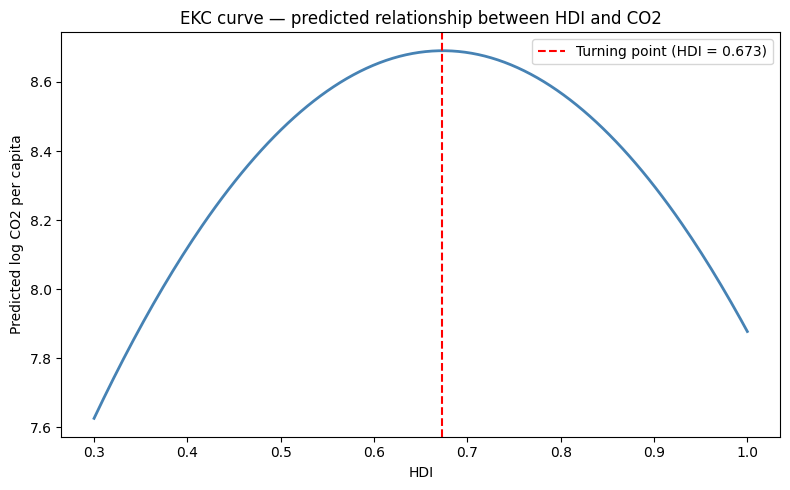

In [19]:
import numpy as np
import matplotlib.pyplot as plt

hdi_range = np.linspace(0.3, 1.0, 200)
log_gdp_mean = np.log(df_panel["gdp_pc"]).mean()

# Predicted log CO2 from just the HDI terms (ignoring fixed effects)
log_co2_pred = 10.2737 * hdi_range + (-7.6266) * hdi_range**2 + 0.6191 * log_gdp_mean

plt.figure(figsize=(8, 5))
plt.plot(hdi_range, log_co2_pred, color="steelblue", linewidth=2)
plt.axvline(x=0.673, color="red", linestyle="--", label="Turning point (HDI = 0.673)")
plt.xlabel("HDI")
plt.ylabel("Predicted log CO2 per capita")
plt.title("EKC curve — predicted relationship between HDI and CO2")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
mod = PanelOLS(
    dependent = df_panel["log_co2_pc"],
    exog = df_panel[["log_gdp_pc", "hdi"]],
    entity_effects = True,
    time_effects = True
)
res = mod.fit(cov_type="clustered", cluster_entity=True)
print(res.summary)

/usr/local/lib/python3.12/dist-packages/linearmodels/panel/model.py:1258: MissingValueWarning: 
Inputs contain missing values. Dropping rows with missing observations.
  super().__init__(dependent, exog, weights=weights, check_rank=check_rank)


                          PanelOLS Estimation Summary                           
Dep. Variable:             log_co2_pc   R-squared:                        0.2105
Estimator:                   PanelOLS   R-squared (Between):             -7.8071
No. Observations:                5685   R-squared (Within):               0.1331
Date:                Mon, Mar 02 2026   R-squared (Overall):             -7.7366
Time:                        14:32:20   Log-likelihood                   -247.36
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      728.71
Entities:                         184   P-value                           0.0000
Avg Obs:                       30.897   Distribution:                  F(2,5466)
Min Obs:                       2.0000                                           
Max Obs:                       34.000   F-statistic (robust):             34.204
                            